# Analyze MP dielectric `.extxyz` exports

This notebook now focuses on **analysis and diagnostics** for dielectric datasets written by `get-mp-dielectrics.py`.

The script owns dataset construction:
- fetch from Materials Project
- optional filtering
- optional deduplication
- train/valid/test split writing

Use the script when you want to regenerate data. A typical command is:

```bash
python get-mp-dielectrics.py   --out MP-Dielectrics.extxyz   --write-filtered   --dedupe-filtered   --write-splits
```

This notebook reads the raw and filtered outputs, builds analysis DataFrames, and helps inspect the structures that were kept or dropped.


In [1]:
from ase.io import read
import numpy as np
import pandas as pd
from pathlib import Path

RAW_PATH = Path("MP-Dielectrics.extxyz")
FILTERED_PATH = Path("MP-Dielectrics-filtered.extxyz")
UNIQUE_PATH = None  # Optionally point this at a separately deduplicated file.


def read_frames(path):
    if path is None:
        return []
    path = Path(path)
    if not path.exists():
        print(f"Missing: {path}")
        return []
    frames = read(str(path), ":")
    return frames if isinstance(frames, list) else [frames]


frames = read_frames(RAW_PATH)
filtered_frames = read_frames(FILTERED_PATH)
unique_frames = read_frames(UNIQUE_PATH) if UNIQUE_PATH else list(filtered_frames)

print({
    "raw": len(frames),
    "filtered": len(filtered_frames),
    "unique": len(unique_frames),
})
frames[0] if frames else None


{'raw': 7332, 'filtered': 5281, 'unique': 5281}


Atoms(symbols='Cl16', pbc=True, cell=[8.203525, 11.765809, 11.765809], REF_becs=..., REF_forces=...)

In [2]:
from ase.visualize import view
view(frames[3], viewer='ngl')

## Parse metadata & build analysis DataFrames

Expected fields from the exporter:
- `REF_energy` (info)
- `REF_forces` (arrays, N×3)
- `REF_becs` (arrays, N×9)
- `REF_stress` (info, flattened 9 or 6) in **eV/Å³**
- `REF_epsilon_*` (info, flattened 9)
- `REF_polarizability` (info, flattened 9; susceptibility tensor χ = ε − I)
- optional `config_*_weight` in info to disable missing labels
- optional `filter_source_index` in filtered outputs, written by the script


In [3]:
def get_info(atoms, key, default=None):
    return atoms.info.get(key, default)


def as_tensor9(x):
    if x is None:
        return None
    a = np.array(x, dtype=float).reshape(-1)
    if a.size != 9:
        return None
    return a.reshape(3, 3)


def build_df(frames):
    rows = []
    for i, at in enumerate(frames):
        eps_static = as_tensor9(get_info(at, "REF_epsilon_static"))
        eps_ionic = as_tensor9(get_info(at, "REF_epsilon_ionic"))
        eps_total = as_tensor9(get_info(at, "REF_epsilon_total"))
        if eps_total is None and eps_static is not None and eps_ionic is not None:
            eps_total = eps_static + eps_ionic

        pol = get_info(at, "REF_polarizability")
        try:
            pol = None if pol is None else np.array(pol, dtype=float).reshape(-1)
            if pol is not None and pol.size != 9:
                pol = None
        except Exception:
            pol = None

        energy = get_info(at, "REF_energy")
        stress_raw = get_info(at, "REF_stress")  # already eV/Å^3
        stress = None
        if stress_raw is not None:
            s = np.array(stress_raw, dtype=float).reshape(-1)
            if s.size == 9:
                stress = s.reshape(3, 3)
            elif s.size == 6:
                stress = s

        forces = at.arrays.get("REF_forces", None)
        bec9 = at.arrays.get("REF_becs", None)

        bec = None
        if bec9 is not None and bec9.ndim == 2 and bec9.shape[1] == 9:
            bec = np.array(bec9, dtype=float).reshape(len(at), 3, 3)

        w_forces = get_info(at, "config_forces_weight", 1.0)
        w_becs = get_info(at, "config_becs_weight", 1.0)
        w_stress = get_info(at, "config_stress_weight", 1.0)
        w_pol = get_info(at, "config_polarizability_weight", 1.0)

        max_force = None
        if forces is not None:
            try:
                max_force = float(np.max(np.linalg.norm(np.array(forces, dtype=float), axis=1)))
            except Exception:
                max_force = None

        def diel_scalar(eps):
            return None if eps is None else float(np.linalg.eigvalsh(eps).mean())

        rows.append({
            "i": i,
            "filter_source_index": get_info(at, "filter_source_index"),
            "material_id": get_info(at, "material_id"),
            "dielectric_task_id": get_info(at, "dielectric_task_id"),
            "n": len(at),
            "volume": float(at.get_volume()),
            "REF_energy": float(energy) if energy is not None else None,
            "max_force": max_force,
            "stress": stress,
            "stress_units": get_info(at, "REF_stress_units"),
            "eps_total": eps_total,
            "eps_total_scalar": diel_scalar(eps_total),
            "REF_polarizability": pol,
            "bec": bec,
            "w_forces": float(w_forces) if w_forces is not None else 1.0,
            "w_becs": float(w_becs) if w_becs is not None else 1.0,
            "w_stress": float(w_stress) if w_stress is not None else 1.0,
            "w_pol": float(w_pol) if w_pol is not None else 1.0,
            "atoms": at,
        })

    return pd.DataFrame(rows)


df = build_df(frames)
df_f = build_df(filtered_frames) if filtered_frames else df.copy()
df_u = build_df(unique_frames) if unique_frames else df_f.copy()

df.head(), {"raw": len(df), "filtered": len(df_f), "unique": len(df_u)}


(   i filter_source_index material_id dielectric_task_id   n       volume  \
 0  0                None   mp-570778         mp-1140435  16  1135.648924   
 1  1                None   mp-632291         mp-1141313   2    23.550470   
 2  2                None   mp-850274         mp-1142038   2    22.794998   
 3  3                None   mp-555760         mp-1114900   9   271.700733   
 4  4                None   mp-567313         mp-1119522   3   104.552874   
 
    REF_energy  max_force                                             stress  \
 0  -28.833351   0.023126  [[0.0004838232252, -0.0, -0.0], [-0.0, 0.00021...   
 1   -6.783037   0.017024  [[0.002058999193, 0.0, 0.0], [0.0, 0.002058999...   
 2   -6.778815   0.026321  [[0.002586371562, 0.0, 0.0], [0.0, 0.002586371...   
 3  -36.863358   0.010162  [[0.001153776847, 0.0, 0.0], [0.0, 0.001153776...   
 4   -9.430569   0.004657  [[0.0004520699595, 0.0, 0.0], [0.0, 0.00045207...   
 
   stress_units                                       

## Dataset inventory

These are the files currently loaded for analysis. The notebook does not rewrite them.


In [4]:
for label, dataset_path, dataset_df in [
    ("raw", RAW_PATH, df),
    ("filtered", FILTERED_PATH, df_f),
    ("unique", UNIQUE_PATH if UNIQUE_PATH else FILTERED_PATH, df_u),
]:
    print(f"{label:>8}: {dataset_path} -> {len(dataset_df)} frames")


     raw: MP-Dielectrics.extxyz -> 7332 frames
filtered: MP-Dielectrics-filtered.extxyz -> 5281 frames
  unique: MP-Dielectrics-filtered.extxyz -> 5281 frames


## Quick sanity check


In [5]:
from ase.io import read
import numpy as np

chk = read(str(RAW_PATH), ":") if RAW_PATH.exists() else []
print("frames:", len(chk))
if chk:
    print("REF_energy:", chk[0].info.get("REF_energy"))
    print("REF_stress_units:", chk[0].info.get("REF_stress_units"))
    print("REF_stress len:", len(np.array(chk[0].info.get("REF_stress")).reshape(-1)) if "REF_stress" in chk[0].info else None)
    print("REF_polarizability shape:", np.array(chk[0].info.get("REF_polarizability")).shape if "REF_polarizability" in chk[0].info else None)
    print("REF_becs shape (N,9):", chk[0].arrays["REF_becs"].shape if "REF_becs" in chk[0].arrays else None)
    print("REF_forces shape:", chk[0].arrays["REF_forces"].shape if "REF_forces" in chk[0].arrays else None)


frames: 7332
REF_energy: -28.83335112
REF_stress_units: None
REF_stress len: 9
REF_polarizability shape: (9,)
REF_becs shape (N,9): (16, 9)
REF_forces shape: (16, 3)


# Dataset analysis & statistics plots

This section makes sanity-check and exploratory plots using **matplotlib**.
It assumes the raw and optional filtered outputs have already been loaded from disk into `df`, `df_f`, and `df_u`.

If you only want to analyze one dataset, set `ANALYZE` below to `"raw"`, `"filtered"`, or `"unique"`.


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ANALYZE = "unique"  # "raw" | "filtered" | "unique"
if ANALYZE == "raw":
    dfa = df.copy()
elif ANALYZE == "filtered":
    dfa = df_f.copy()
elif ANALYZE == "unique":
    dfa = df_u.copy()
else:
    raise ValueError("ANALYZE must be 'raw', 'filtered', or 'unique'")

print("Analyzing:", ANALYZE, "n_structures=", len(dfa))


Analyzing: unique n_structures= 5281


## Convenience derived quantities


In [7]:
def safe_float(x):
    try:
        if x is None:
            return np.nan
        return float(x)
    except Exception:
        return np.nan

dfa["energy_per_atom"] = dfa["REF_energy"].apply(safe_float) / dfa["n"].astype(float)

def stress_mag_ev_a3(stress):
    if stress is None:
        return np.nan
    s = np.array(stress, dtype=float).reshape(-1)
    return float(np.max(np.abs(s)))

dfa["stress_mag_ev_a3"] = dfa["stress"].apply(stress_mag_ev_a3)
GPA_PER_EV_A3 = 160.21766208
dfa["stress_mag_gpa"] = dfa["stress_mag_ev_a3"] * GPA_PER_EV_A3

def eps_eigs(eps):
    if eps is None:
        return (np.nan, np.nan, np.nan)
    e = np.array(eps, dtype=float).reshape(3,3)
    e = 0.5*(e + e.T)
    w = np.linalg.eigvalsh(e)
    return tuple(float(x) for x in w)

eigs = dfa["eps_total"].apply(eps_eigs)
dfa["eps_eig1"] = [t[0] for t in eigs]
dfa["eps_eig2"] = [t[1] for t in eigs]
dfa["eps_eig3"] = [t[2] for t in eigs]
dfa["eps_eig_min"] = dfa[["eps_eig1","eps_eig2","eps_eig3"]].min(axis=1)
dfa["eps_eig_max"] = dfa[["eps_eig1","eps_eig2","eps_eig3"]].max(axis=1)

def pol_diag(pol):
    if pol is None:
        return (np.nan, np.nan, np.nan)
    p = np.array(pol, dtype=float).reshape(-1)
    if p.size != 9:
        return (np.nan, np.nan, np.nan)
    P = p.reshape(3,3)
    return (float(P[0,0]), float(P[1,1]), float(P[2,2]))

pdg = dfa["REF_polarizability"].apply(pol_diag)
dfa["chi_xx"] = [t[0] for t in pdg]
dfa["chi_yy"] = [t[1] for t in pdg]
dfa["chi_zz"] = [t[2] for t in pdg]
dfa["chi_trace"] = dfa[["chi_xx","chi_yy","chi_zz"]].sum(axis=1)

if "bec_asr_norm_num" in dfa.columns:
    dfa["bec_asr_norm"] = pd.to_numeric(dfa["bec_asr_norm_num"], errors="coerce")
elif "bec_asr_norm" in dfa.columns:
    dfa["bec_asr_norm"] = pd.to_numeric(dfa["bec_asr_norm"], errors="coerce")
else:
    def asr_norm(bec):
        if bec is None:
            return np.nan
        s = np.sum(bec, axis=0)
        return float(np.linalg.norm(s))
    dfa["bec_asr_norm"] = dfa["bec"].apply(asr_norm)

for col in ["volume","max_force","eps_total_scalar","energy_per_atom","stress_mag_ev_a3","stress_mag_gpa","bec_asr_norm","chi_trace"]:
    dfa[col] = pd.to_numeric(dfa[col], errors="coerce")

dfa[["n","volume","REF_energy","energy_per_atom","max_force","stress_mag_gpa","eps_total_scalar","bec_asr_norm","chi_trace"]].describe()


,n,volume,REF_energy,energy_per_atom,max_force,stress_mag_gpa,eps_total_scalar,bec_asr_norm,chi_trace
count,5281.000000,5281.000000,5281.000000,5281.000000,5281.000000,5281.000000,5281.000000,5281.000000,5.281000e+03
mean,16.922553,324.393446,-94.297105,-5.270731,0.011123,0.090852,16.970642,0.012040,1.593757e+01
std,13.148030,248.747568,89.502650,1.616079,0.013450,0.210750,18.340199,0.037272,2.189722e+01
min,1.000000,13.980548,-983.455328,-10.703475,0.000000,0.000047,1.155248,0.000000,3.308722e-24
25%,8.000000,158.170724,-114.656606,-6.464404,0.000913,0.005860,8.102739,0.000035,6.172073e+00
50%,14.000000,259.247607,-71.205395,-5.130471,0.004775,0.029903,11.592690,0.000057,1.023634e+01
75%,20.000000,413.770230,-38.747157,-3.989407,0.018119,0.112381,18.678607,0.003087,1.725266e+01
max,160.000000,2454.280496,-0.217246,-0.217246,0.049924,8.652531,186.117394,0.283878,5.315389e+02


## Basic dataset summaries


In [8]:
key_cols = ["REF_energy","energy_per_atom","max_force","stress_mag_gpa","eps_total_scalar","bec_asr_norm","chi_trace"]
missing = {c: int(dfa[c].isna().sum()) for c in key_cols}
missing


{'REF_energy': 0,
 'energy_per_atom': 0,
 'max_force': 0,
 'stress_mag_gpa': 0,
 'eps_total_scalar': 0,
 'bec_asr_norm': 0,
 'chi_trace': 0}

In [9]:
from collections import Counter

elem_counts = Counter()
for at in dfa["atoms"].values:
    elem_counts.update(at.get_chemical_symbols())

elem_counts.most_common(20)


[('O', 21355),
 ('F', 5593),
 ('N', 5326),
 ('S', 4923),
 ('Li', 2943),
 ('Se', 2926),
 ('H', 2843),
 ('Na', 2675),
 ('Cl', 2573),
 ('P', 2406),
 ('K', 2076),
 ('Si', 1730),
 ('Ba', 1496),
 ('Te', 1407),
 ('Sr', 1395),
 ('Cs', 1352),
 ('Ca', 1348),
 ('Br', 1271),
 ('Rb', 1265),
 ('I', 1264)]

## Histograms


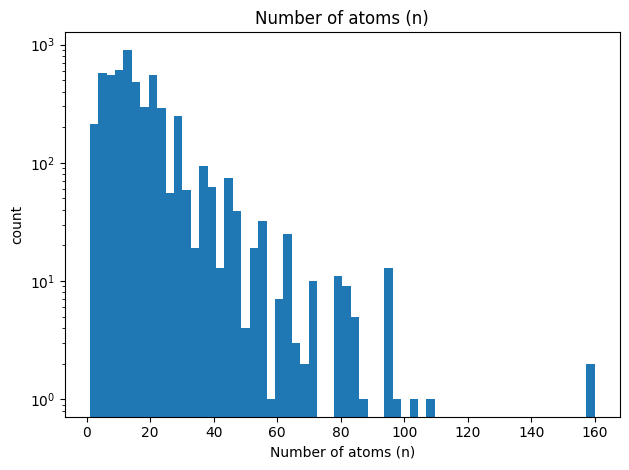

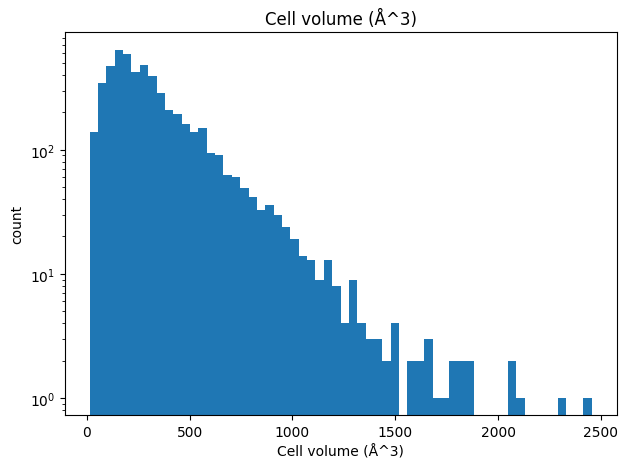

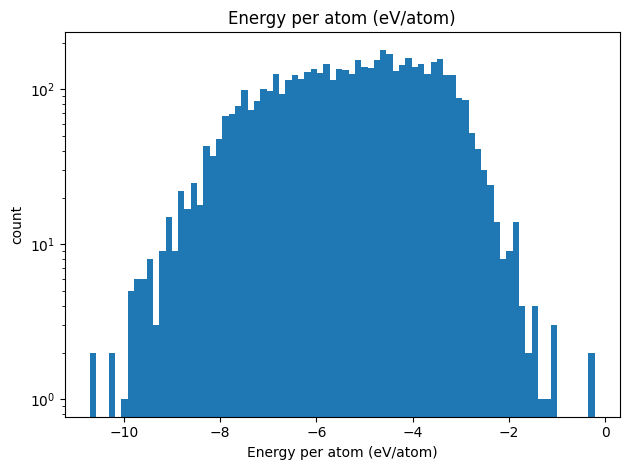

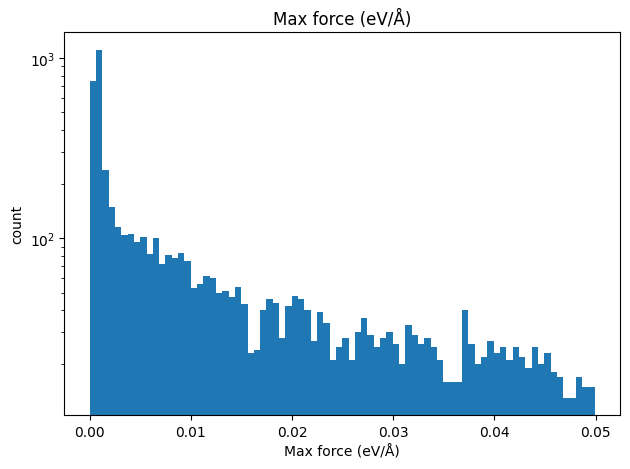

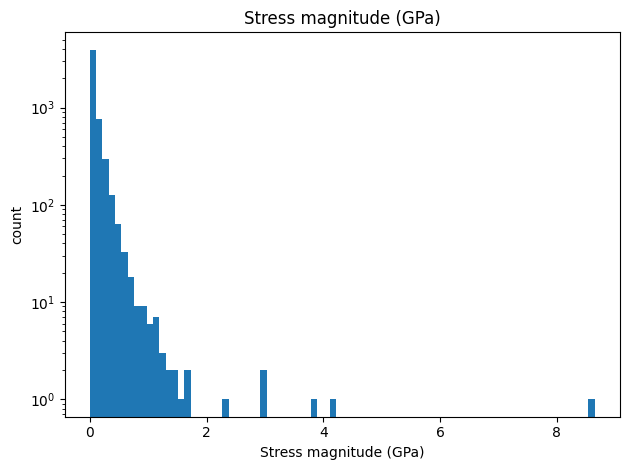

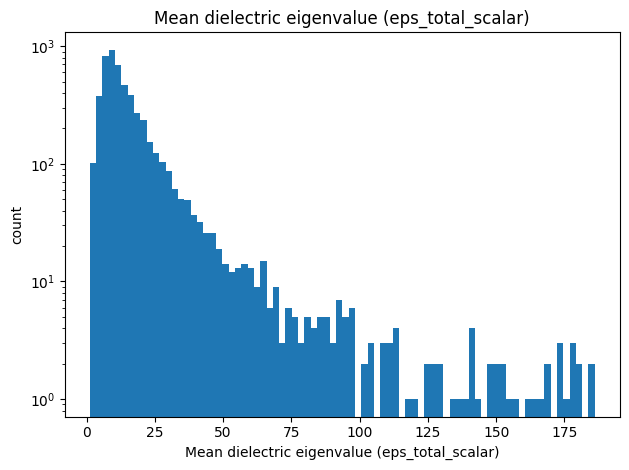

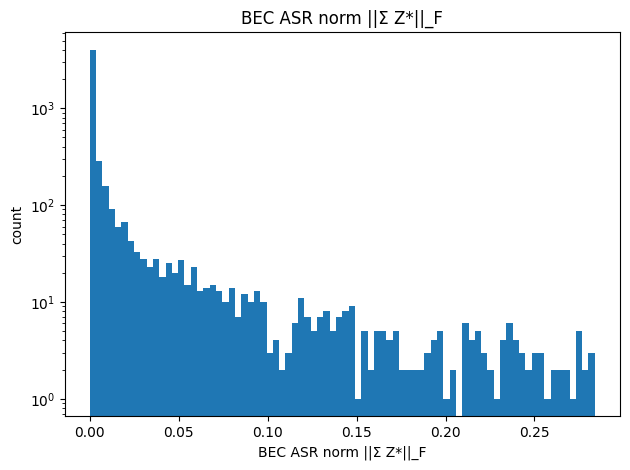

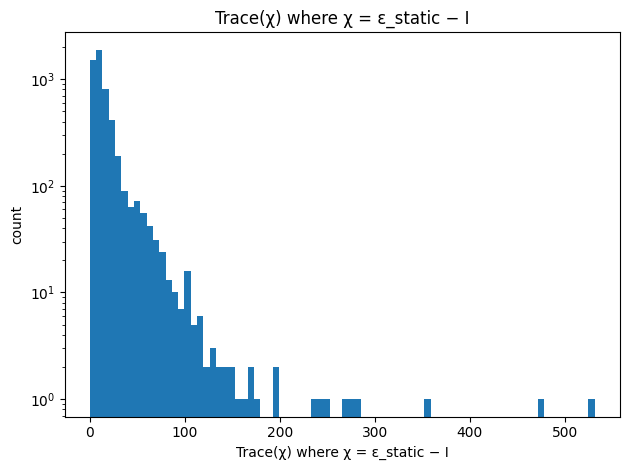

In [10]:
def hist(series, title, bins=50, logy=False):
    x = pd.to_numeric(series, errors="coerce").dropna().values
    plt.figure()
    plt.hist(x, bins=bins)
    plt.title(title)
    plt.xlabel(title)
    plt.ylabel("count")
    if logy:
        plt.yscale("log")
    plt.tight_layout()
    plt.show()

hist(dfa["n"], "Number of atoms (n)", bins=60, logy=True)
hist(dfa["volume"], "Cell volume (Å^3)", bins=60, logy=True)
hist(dfa["energy_per_atom"], "Energy per atom (eV/atom)", bins=80, logy=True)
hist(dfa["max_force"], "Max force (eV/Å)", bins=80, logy=True)
hist(dfa["stress_mag_gpa"], "Stress magnitude (GPa)", bins=80, logy=True)
hist(dfa["eps_total_scalar"], "Mean dielectric eigenvalue (eps_total_scalar)", bins=80, logy=True)
hist(dfa["bec_asr_norm"], "BEC ASR norm ||Σ Z*||_F", bins=80, logy=True)
hist(dfa["chi_trace"], "Trace(χ) where χ = ε_static − I", bins=80, logy=True)


## Dielectric eigenvalue distributions


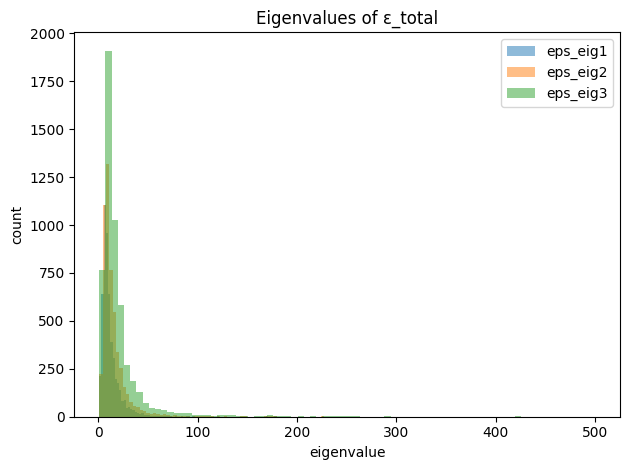

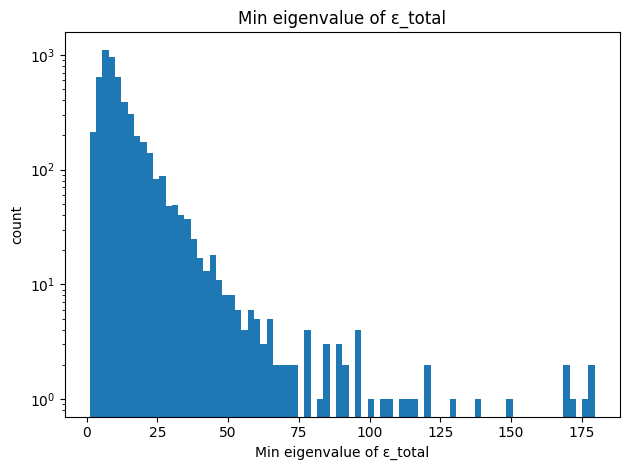

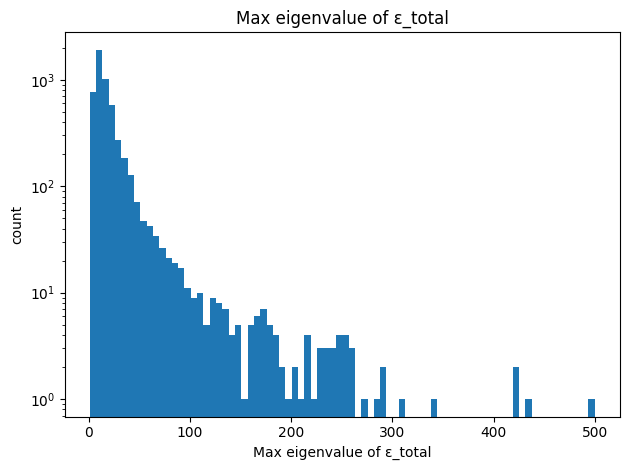

In [11]:
plt.figure()
for col in ["eps_eig1","eps_eig2","eps_eig3"]:
    x = pd.to_numeric(dfa[col], errors="coerce").dropna().values
    plt.hist(x, bins=80, alpha=0.5, label=col)
plt.xlabel("eigenvalue")
plt.ylabel("count")
plt.title("Eigenvalues of ε_total")
plt.legend()
plt.tight_layout()
plt.show()

hist(dfa["eps_eig_min"], "Min eigenvalue of ε_total", bins=80, logy=True)
hist(dfa["eps_eig_max"], "Max eigenvalue of ε_total", bins=80, logy=True)


## Scatter plots for sanity checks


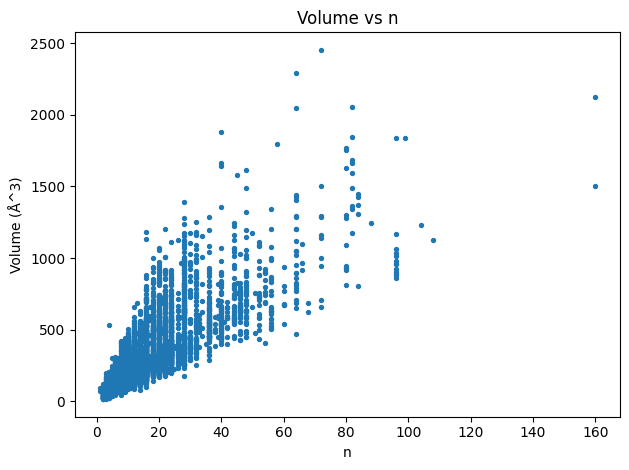

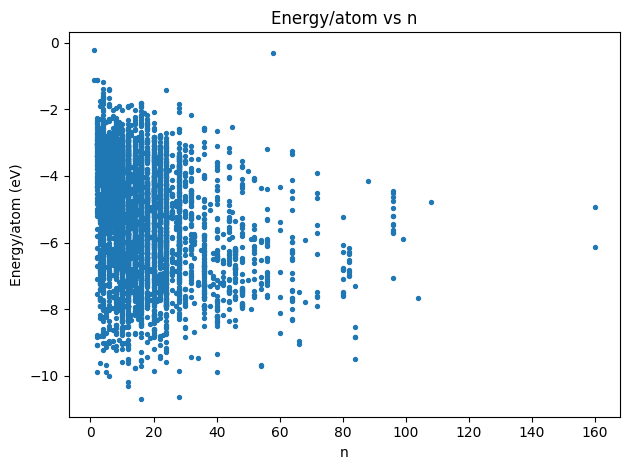

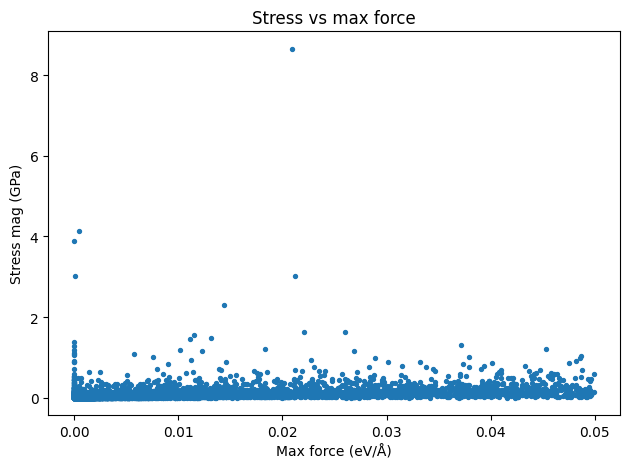

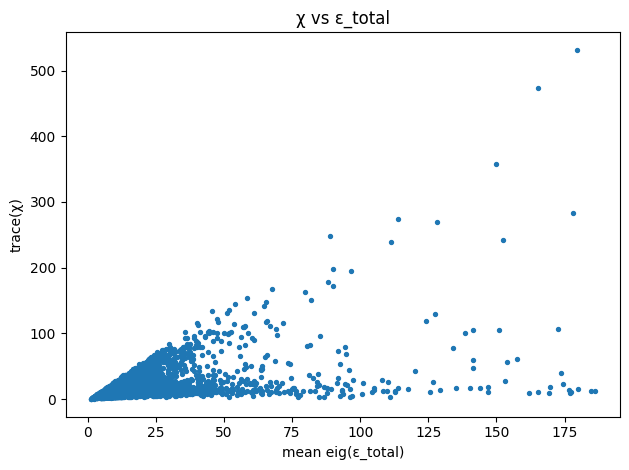

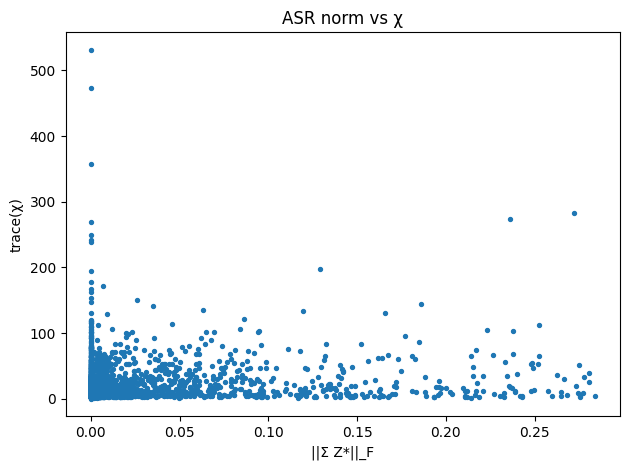

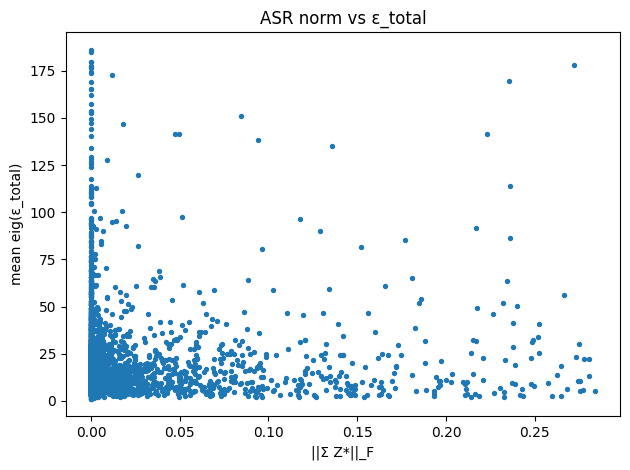

In [12]:
def scatter(x, y, xlabel, ylabel, title, s=8):
    xx = pd.to_numeric(x, errors="coerce")
    yy = pd.to_numeric(y, errors="coerce")
    m = (~xx.isna()) & (~yy.isna())
    plt.figure()
    plt.scatter(xx[m], yy[m], s=s)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

scatter(dfa["n"], dfa["volume"], "n", "Volume (Å^3)", "Volume vs n")
scatter(dfa["n"], dfa["energy_per_atom"], "n", "Energy/atom (eV)", "Energy/atom vs n")
scatter(dfa["max_force"], dfa["stress_mag_gpa"], "Max force (eV/Å)", "Stress mag (GPa)", "Stress vs max force")
scatter(dfa["eps_total_scalar"], dfa["chi_trace"], "mean eig(ε_total)", "trace(χ)", "χ vs ε_total")
scatter(dfa["bec_asr_norm"], dfa["chi_trace"], "||Σ Z*||_F", "trace(χ)", "ASR norm vs χ")
scatter(dfa["bec_asr_norm"], dfa["eps_total_scalar"], "||Σ Z*||_F", "mean eig(ε_total)", "ASR norm vs ε_total")


## Correlation heatmap (numerical features)
Matplotlib-only correlation display for key numeric columns.


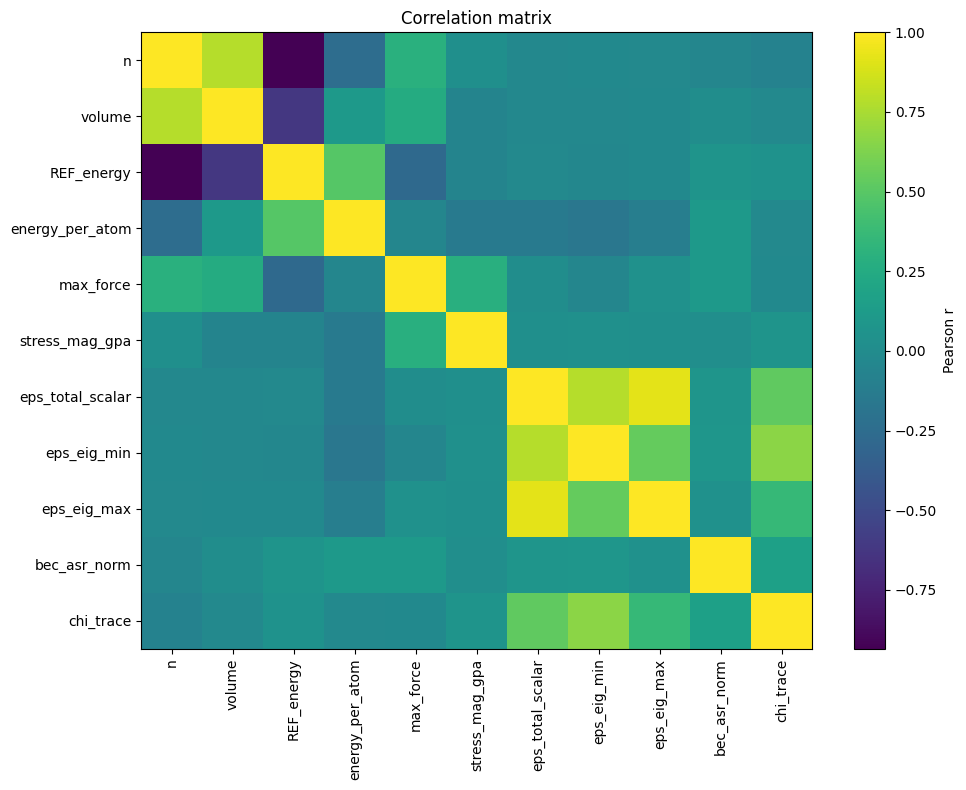

,n,volume,REF_energy,energy_per_atom,max_force,stress_mag_gpa,eps_total_scalar,eps_eig_min,eps_eig_max,bec_asr_norm,chi_trace
n,1.000000,0.781061,-0.934261,-0.240201,0.292879,0.032012,-0.031408,-0.019778,-0.022409,-0.047872,-0.076441
volume,0.781061,1.000000,-0.619009,0.107833,0.254384,-0.058260,-0.029406,-0.032644,-0.012848,0.014581,-0.023896
REF_energy,-0.934261,-0.619009,1.000000,0.492279,-0.274342,-0.063523,-0.021481,-0.039804,-0.014916,0.067319,0.055198
energy_per_atom,-0.240201,0.107833,0.492279,1.000000,-0.046203,-0.145868,-0.142241,-0.164351,-0.104359,0.105791,-0.025484
max_force,0.292879,0.254384,-0.274342,-0.046203,1.000000,0.288424,0.014981,-0.047709,0.041476,0.104633,-0.017005
stress_mag_gpa,0.032012,-0.058260,-0.063523,-0.145868,0.288424,1.000000,0.032804,0.037101,0.026930,0.020395,0.066934
eps_total_scalar,-0.031408,-0.029406,-0.021481,-0.142241,0.014981,0.032804,1.000000,0.784110,0.921245,0.072846,0.526798
eps_eig_min,-0.019778,-0.032644,-0.039804,-0.164351,-0.047709,0.037101,0.784110,1.000000,0.545256,0.079508,0.661396
eps_eig_max,-0.022409,-0.012848,-0.014916,-0.104359,0.041476,0.026930,0.921245,0.545256,1.000000,0.044806,0.362901
bec_asr_norm,-0.047872,0.014581,0.067319,0.105791,0.104633,0.020395,0.072846,0.079508,0.044806,1.000000,0.168542


In [13]:
import matplotlib.pyplot as plt

num_cols = [
    "n","volume","REF_energy","energy_per_atom","max_force","stress_mag_gpa",
    "eps_total_scalar","eps_eig_min","eps_eig_max","bec_asr_norm","chi_trace"
]
M = dfa[num_cols].apply(pd.to_numeric, errors="coerce")
corr = M.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr.values, aspect="auto")
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar(label="Pearson r")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

corr


## Pairwise scatter matrix (subset)
This can be slow for very large datasets; it samples up to `N_SAMPLE` points.


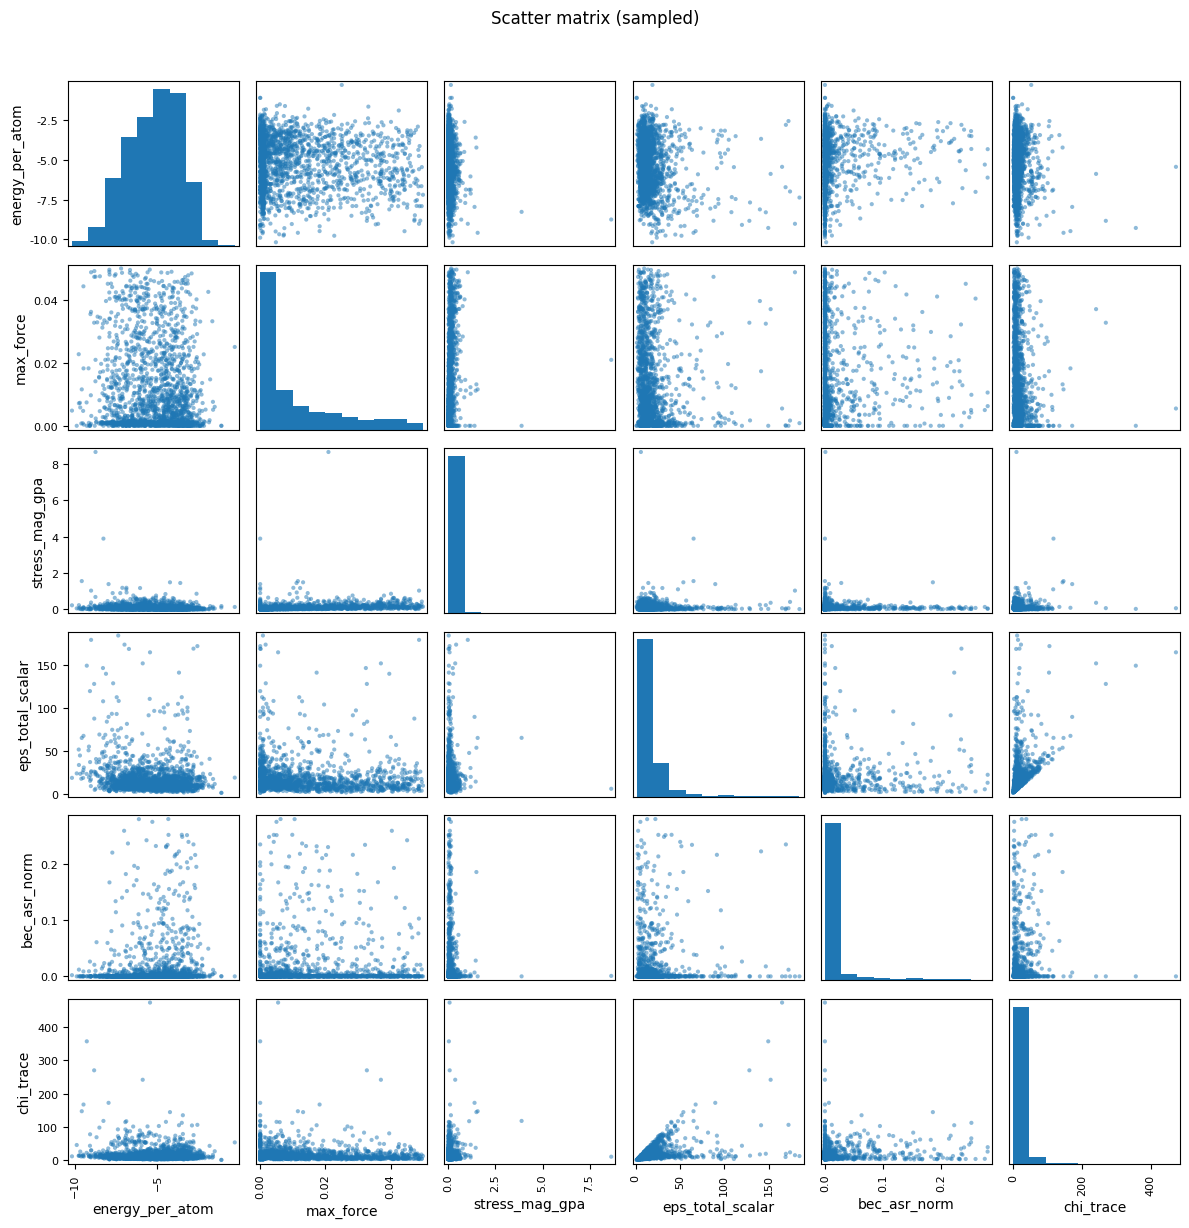

In [14]:
from pandas.plotting import scatter_matrix

N_SAMPLE = 2000
cols = ["energy_per_atom","max_force","stress_mag_gpa","eps_total_scalar","bec_asr_norm","chi_trace"]
X = dfa[cols].apply(pd.to_numeric, errors="coerce").dropna()
if len(X) > N_SAMPLE:
    Xs = X.sample(N_SAMPLE, random_state=0)
else:
    Xs = X

scatter_matrix(Xs, figsize=(12,12), diagonal="hist", alpha=0.5)
plt.suptitle("Scatter matrix (sampled)", y=1.02)
plt.tight_layout()
plt.show()


## Element distribution plots


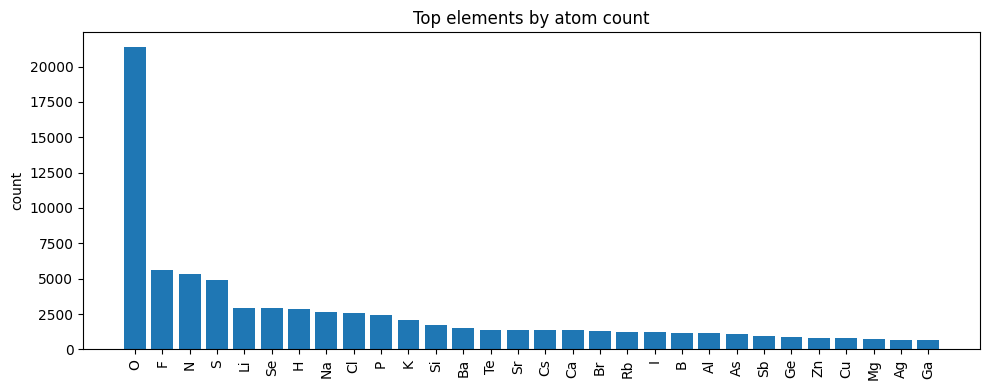

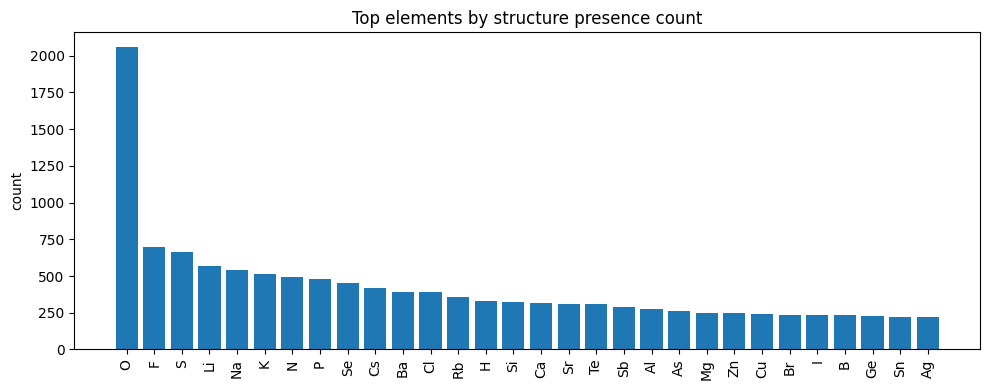

In [15]:
from collections import Counter

elem_counts = Counter()
struct_elem_counts = Counter()

for at in dfa["atoms"].values:
    syms = at.get_chemical_symbols()
    elem_counts.update(syms)
    struct_elem_counts.update(set(syms))

def bar_counter(counter, title, topk=30):
    items = counter.most_common(topk)
    labels = [k for k,_ in items]
    vals = [v for _,v in items]
    plt.figure(figsize=(10,4))
    plt.bar(range(len(labels)), vals)
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.ylabel("count")
    plt.title(title)
    plt.tight_layout()
    plt.show()

bar_counter(elem_counts, "Top elements by atom count", topk=30)
bar_counter(struct_elem_counts, "Top elements by structure presence count", topk=30)


## Per-species BEC norms (optional)
Computes distribution of \|Z*\| per species (Frobenius norm per atom BEC). Can be heavy.


/tmp/ipykernel_2875417/3116488825.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=elems_sorted, showfliers=False)


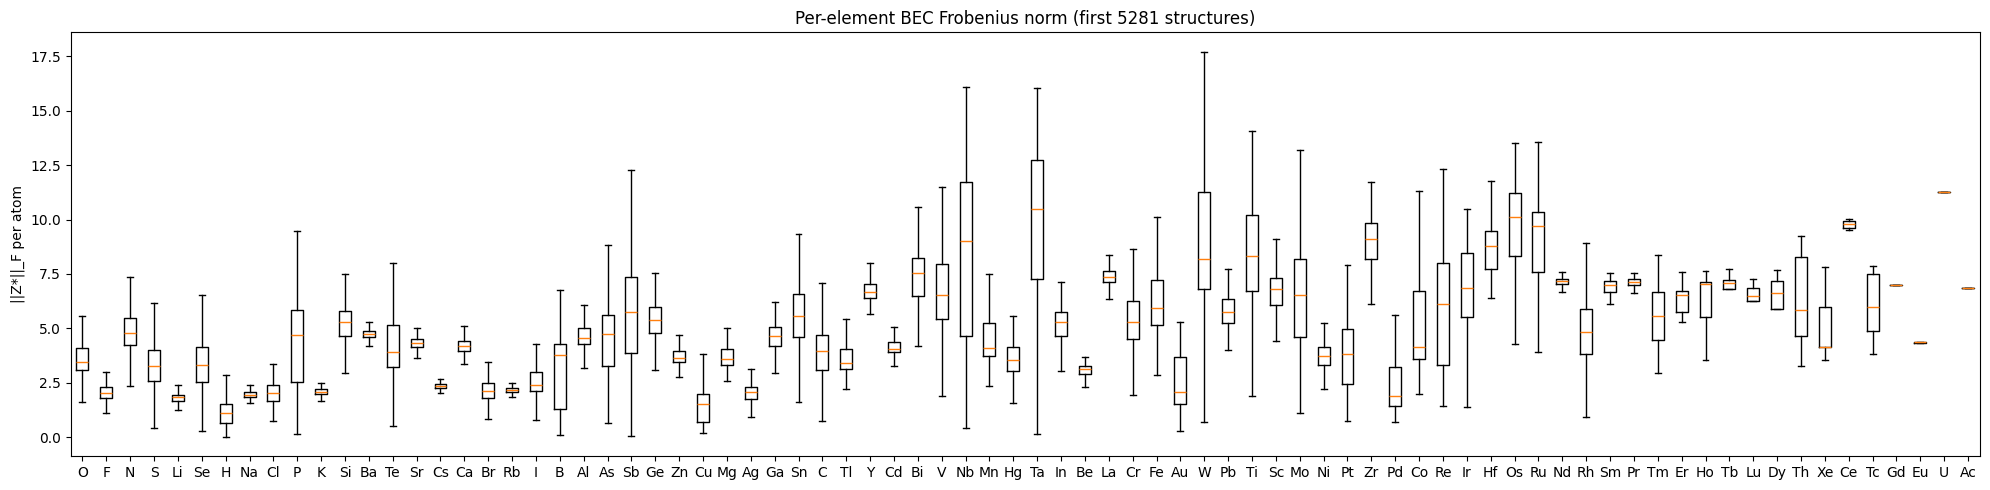

/tmp/ipykernel_2875417/3116488825.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=elems_sorted, showfliers=False)


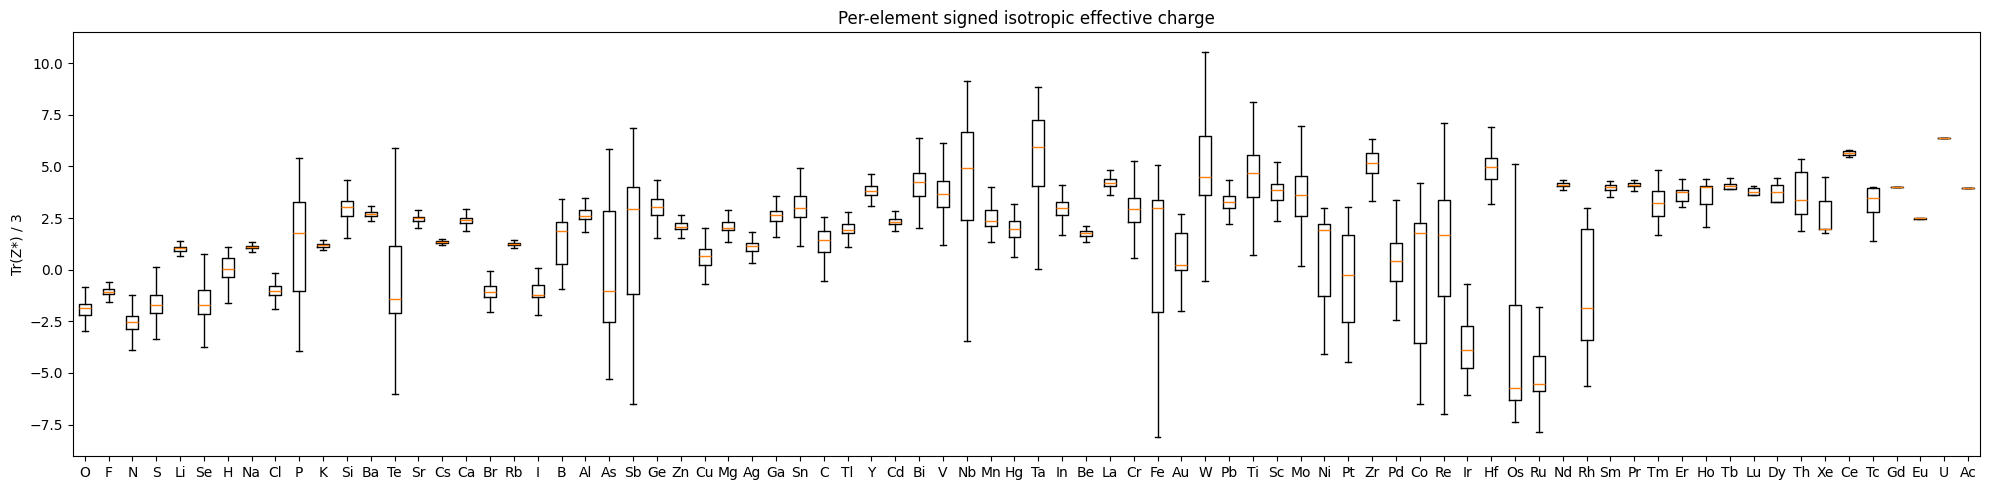

/tmp/ipykernel_2875417/3116488825.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=elems_sorted, showfliers=False)


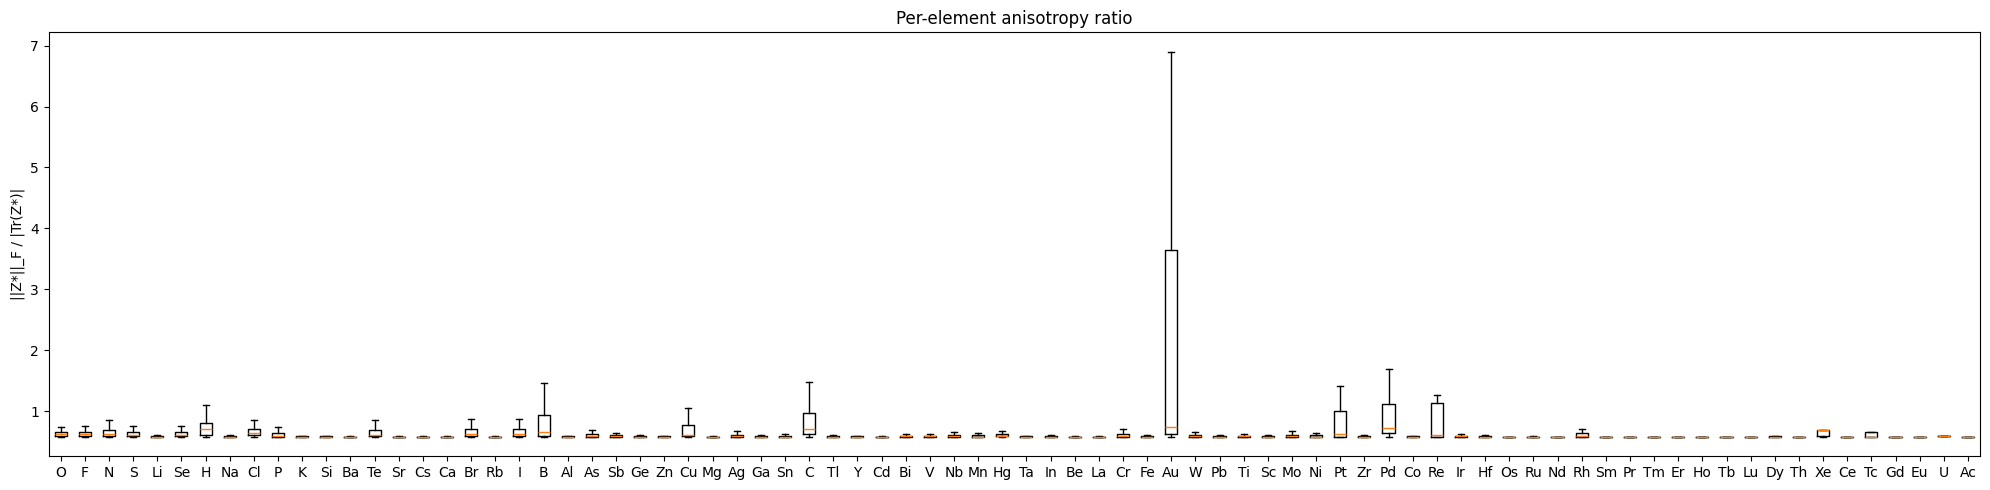

/tmp/ipykernel_2875417/3116488825.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=elems_sorted, showfliers=False)


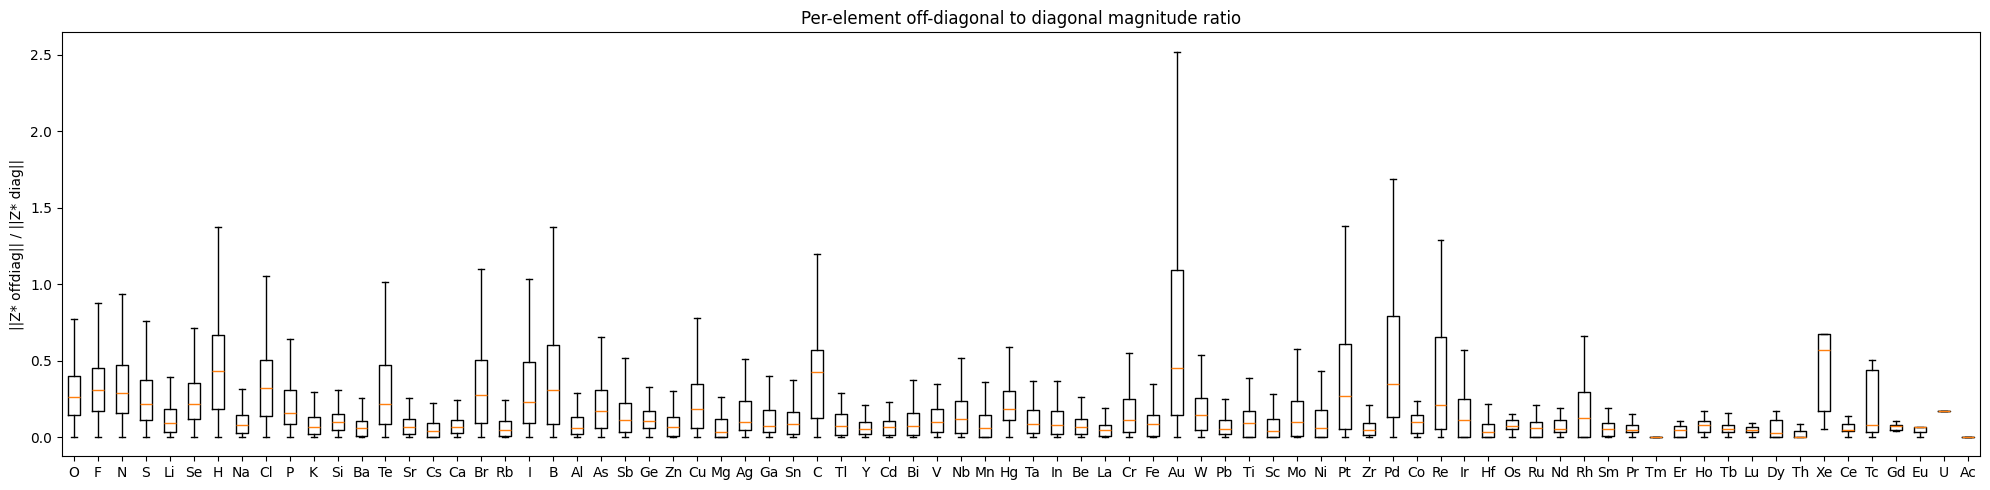

In [16]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

DO_BEC_SPECIES_STATS = True
MAX_STRUCTS_FOR_BEC_STATS = 10000  # cap for speed

if DO_BEC_SPECIES_STATS:
    per_elem_norm = defaultdict(list)
    per_elem_trace = defaultdict(list)
    per_elem_aniso = defaultdict(list)
    per_elem_offdiag_ratio = defaultdict(list)

    n_used = 0

    for at, bec in zip(dfa["atoms"].values, dfa["bec"].values):
        if bec is None:
            continue

        syms = at.get_chemical_symbols()

        for s, z in zip(syms, bec):
            Z = np.array(z, dtype=float).reshape(3, 3)

            # 1️⃣ Frobenius norm
            fnorm = np.linalg.norm(Z)
            per_elem_norm[s].append(float(fnorm))

            # 2️⃣ Signed isotropic effective charge
            trace = np.trace(Z)
            z_iso = trace / 3.0
            per_elem_trace[s].append(float(z_iso))

            # 3️⃣ Anisotropy ratio
            # Avoid division by very small trace
            if abs(trace) > 1e-6:
                aniso = fnorm / abs(trace)
                per_elem_aniso[s].append(float(aniso))

            # 4️⃣ Off-diagonal vs diagonal magnitude ratio
            diag_part = np.diag(np.diag(Z))
            offdiag_part = Z - diag_part

            diag_norm = np.linalg.norm(diag_part)
            offdiag_norm = np.linalg.norm(offdiag_part)

            if diag_norm > 1e-8:
                ratio = offdiag_norm / diag_norm
                per_elem_offdiag_ratio[s].append(float(ratio))

        n_used += 1
        if n_used >= MAX_STRUCTS_FOR_BEC_STATS:
            break

    elems_sorted = sorted(
        per_elem_norm.keys(),
        key=lambda e: len(per_elem_norm[e]),
        reverse=True
    )

    # -----------------------------
    # Plot 1: Frobenius norm
    # -----------------------------
    plt.figure(figsize=(20, 5))
    data = [per_elem_norm[e] for e in elems_sorted]
    plt.boxplot(data, labels=elems_sorted, showfliers=False)
    plt.ylabel("||Z*||_F per atom")
    plt.title(f"Per-element BEC Frobenius norm (first {n_used} structures)")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Plot 2: Signed isotropic charge (Tr/3)
    # -----------------------------
    plt.figure(figsize=(20, 5))
    data = [per_elem_trace[e] for e in elems_sorted]
    plt.boxplot(data, labels=elems_sorted, showfliers=False)
    plt.ylabel("Tr(Z*) / 3")
    plt.title("Per-element signed isotropic effective charge")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Plot 3: Anisotropy ratio
    # -----------------------------
    plt.figure(figsize=(20, 5))
    data = [per_elem_aniso[e] for e in elems_sorted]
    plt.boxplot(data, labels=elems_sorted, showfliers=False)
    plt.ylabel("||Z*||_F / |Tr(Z*)|")
    plt.title("Per-element anisotropy ratio")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Plot 4: Off-diagonal / diagonal ratio
    # -----------------------------
    plt.figure(figsize=(20, 5))
    data = [per_elem_offdiag_ratio[e] for e in elems_sorted]
    plt.boxplot(data, labels=elems_sorted, showfliers=False)
    plt.ylabel("||Z* offdiag|| / ||Z* diag||")
    plt.title("Per-element off-diagonal to diagonal magnitude ratio")
    plt.tight_layout()
    plt.show()

else:
    print("Skipped BEC species stats.")

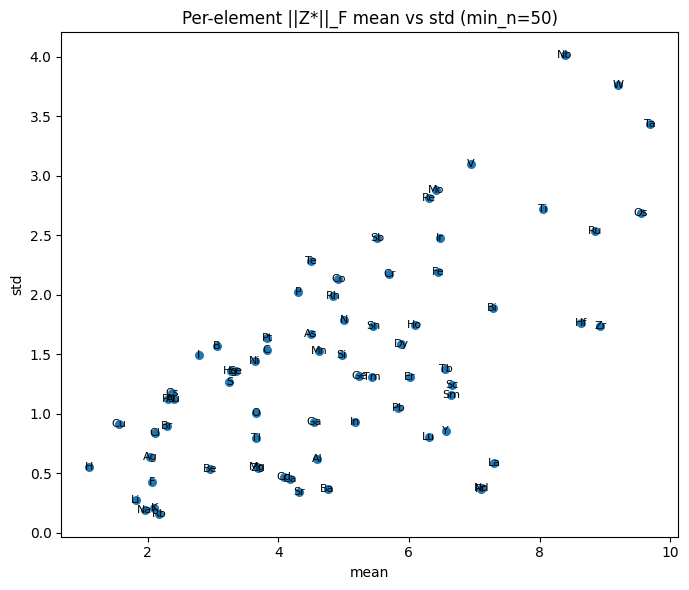

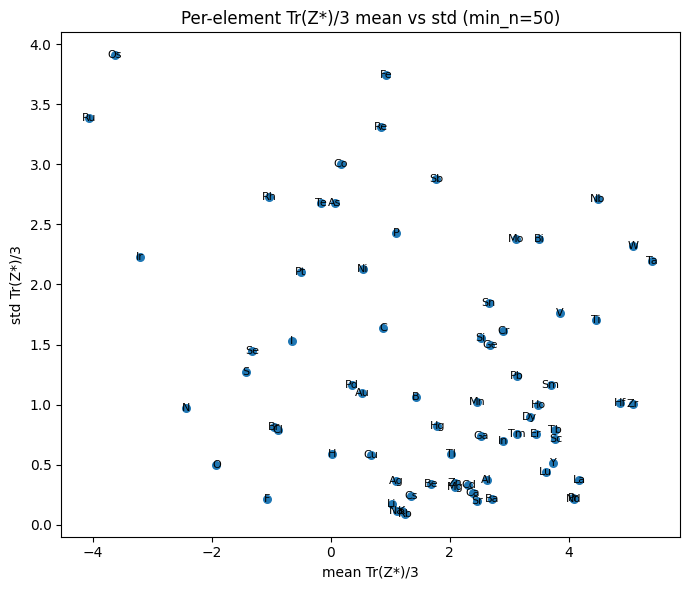

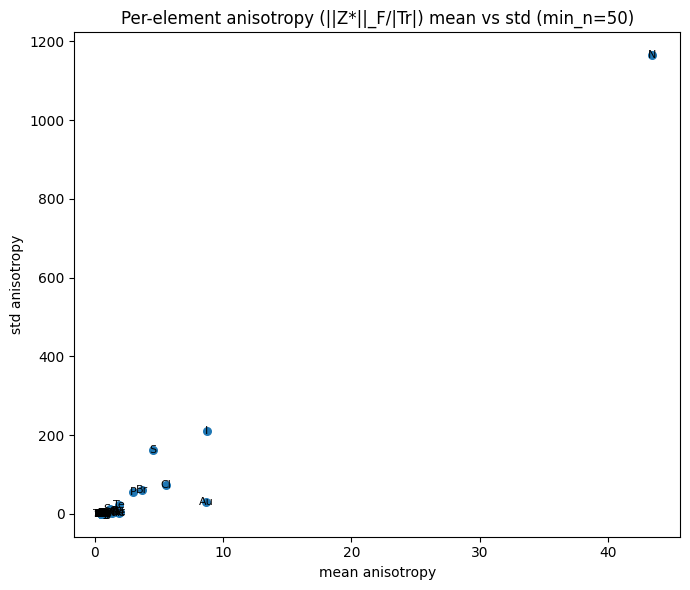

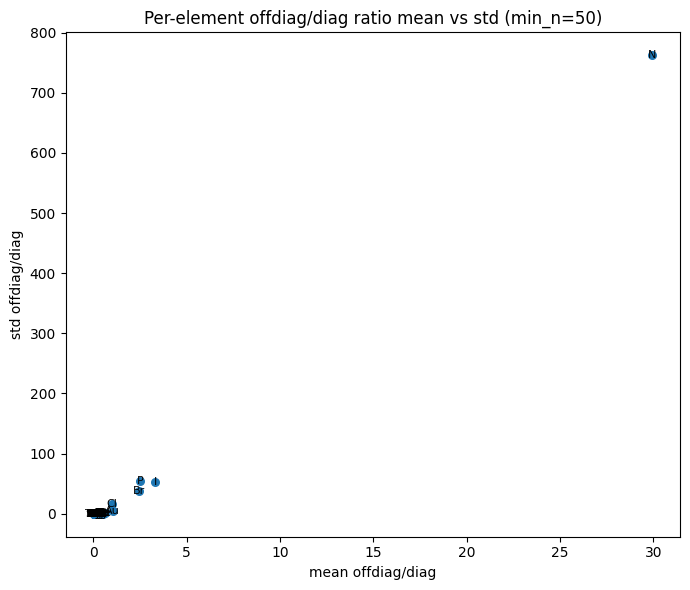

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def elem_mean_std(d):
    out = {}
    for e, vals in d.items():
        v = np.array(vals, dtype=float)
        v = v[np.isfinite(v)]
        if len(v) == 0:
            continue
        out[e] = (float(v.mean()), float(v.std()), int(len(v)))
    return out

stats_norm = elem_mean_std(per_elem_norm)
stats_trace = elem_mean_std(per_elem_trace)
stats_aniso = elem_mean_std(per_elem_aniso)
stats_offdiag = elem_mean_std(per_elem_offdiag_ratio)

def scatter_mean_std(stats, title, xlabel="mean", ylabel="std", min_n=50):
    xs, ys, labels = [], [], []
    for e in elems_sorted:
        if e not in stats:
            continue
        mu, sd, n = stats[e]
        if n < min_n:
            continue
        xs.append(mu); ys.append(sd); labels.append(e)

    plt.figure(figsize=(7,6))
    plt.scatter(xs, ys, s=30)
    for x, y, lab in zip(xs, ys, labels):
        plt.text(x, y, lab, fontsize=8, ha="center", va="center")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title + f" (min_n={min_n})")
    plt.tight_layout()
    plt.show()

scatter_mean_std(stats_norm,  "Per-element ||Z*||_F mean vs std")
scatter_mean_std(stats_trace, "Per-element Tr(Z*)/3 mean vs std", xlabel="mean Tr(Z*)/3", ylabel="std Tr(Z*)/3")
scatter_mean_std(stats_aniso, "Per-element anisotropy (||Z*||_F/|Tr|) mean vs std", xlabel="mean anisotropy", ylabel="std anisotropy")
scatter_mean_std(stats_offdiag, "Per-element offdiag/diag ratio mean vs std", xlabel="mean offdiag/diag", ylabel="std offdiag/diag")

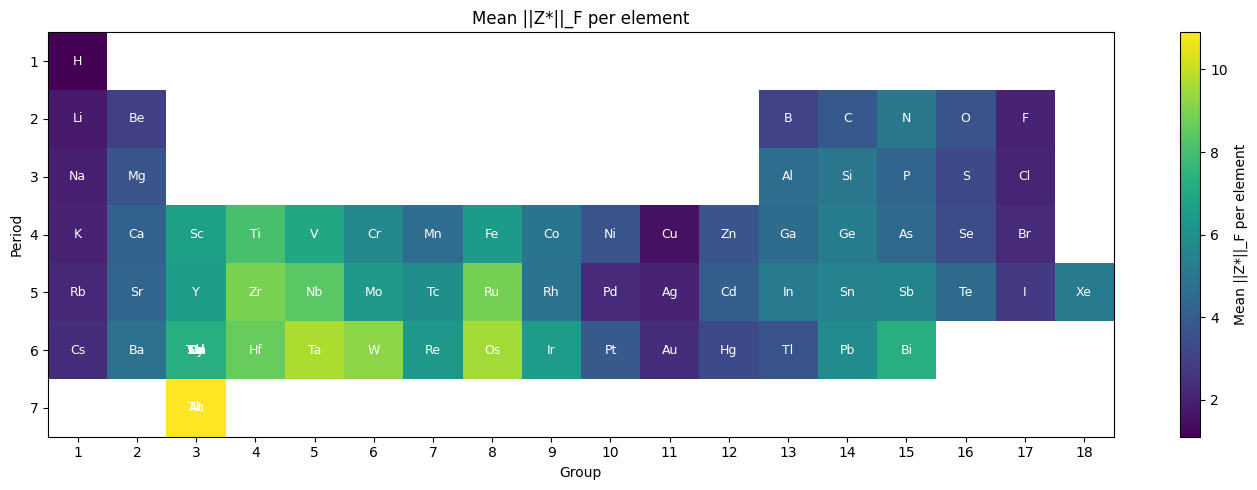

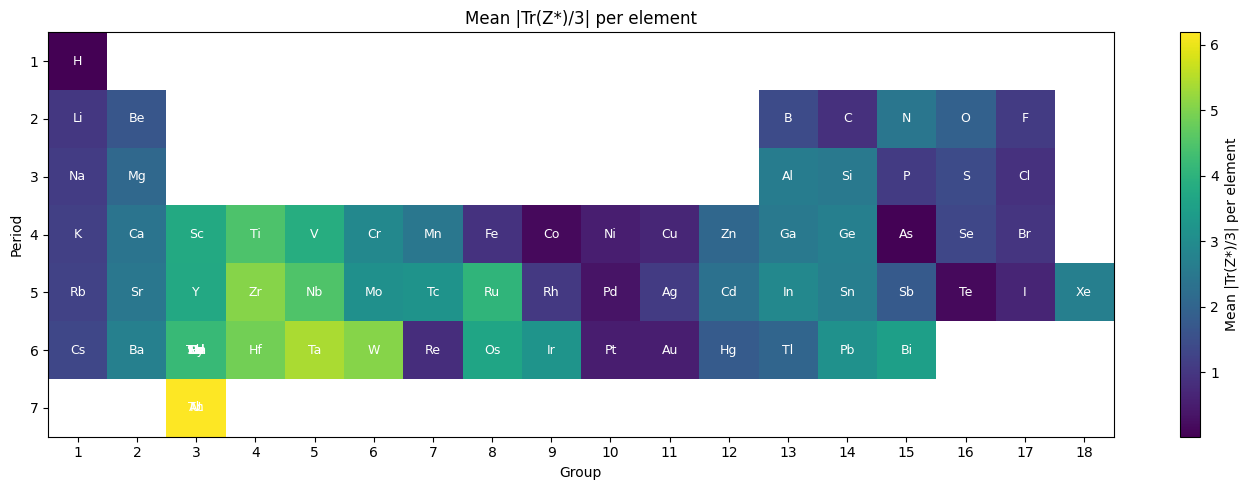

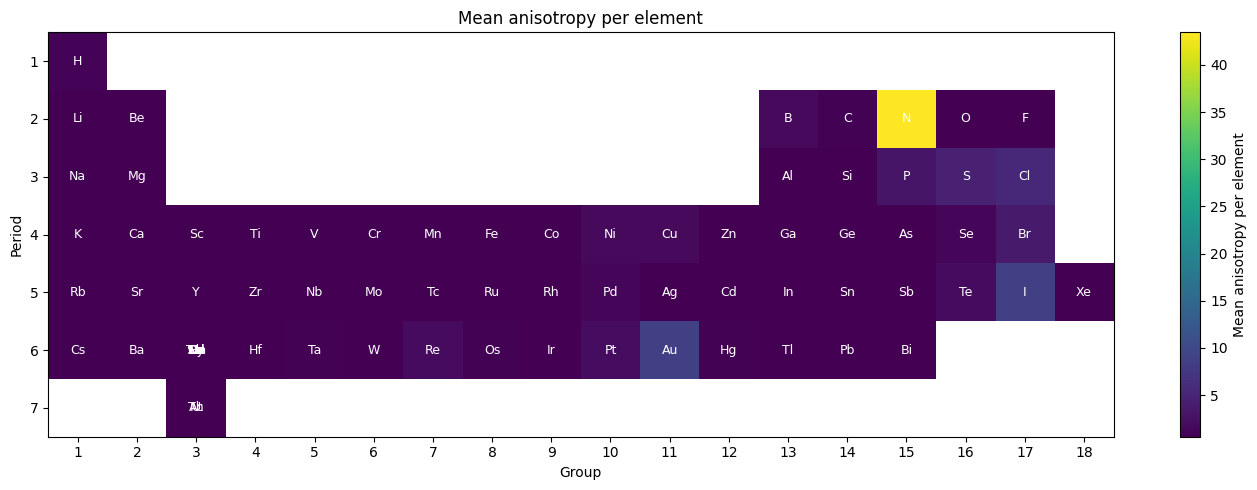

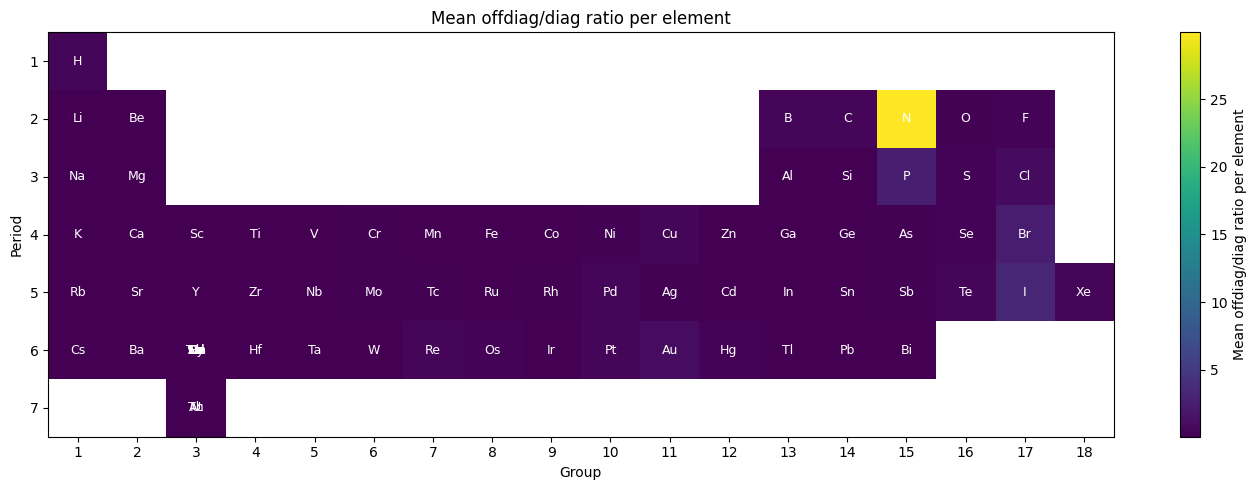

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from pymatgen.core.periodic_table import Element

def periodic_table_heatmap(value_by_elem, title, vmin=None, vmax=None, cmap="viridis"):
    # Grid: periods 1..7, groups 1..18
    grid = np.full((7, 18), np.nan, dtype=float)

    for sym, val in value_by_elem.items():
        try:
            el = Element(sym)
            p = el.row      # 1..7
            g = el.group    # 1..18 (None for some; skip)
            if p is None or g is None:
                continue
            grid[p-1, g-1] = float(val)
        except Exception:
            continue

    plt.figure(figsize=(14, 5))
    im = plt.imshow(grid, aspect="auto", vmin=vmin, vmax=vmax)

    # annotate element symbols
    for sym, val in value_by_elem.items():
        try:
            el = Element(sym)
            p = el.row
            g = el.group
            if p is None or g is None:
                continue
            r, c = p-1, g-1
            if np.isfinite(grid[r, c]):
                plt.text(c, r, sym, ha="center", va="center", fontsize=9, color="white")
        except Exception:
            continue

    plt.xticks(range(18), range(1, 19))
    plt.yticks(range(7), range(1, 8))
    plt.xlabel("Group")
    plt.ylabel("Period")
    plt.title(title)
    plt.colorbar(im, label=title)
    plt.tight_layout()
    plt.show()

# Choose what you want to map:
mean_norm = {e: stats_norm[e][0] for e in stats_norm}                      # mean ||Z*||_F
mean_abs_iso = {e: abs(stats_trace[e][0]) for e in stats_trace}            # mean |Tr(Z*)/3|
mean_aniso = {e: stats_aniso[e][0] for e in stats_aniso}                   # mean anisotropy
mean_offdiag = {e: stats_offdiag[e][0] for e in stats_offdiag}             # mean offdiag/diag

periodic_table_heatmap(mean_norm,     "Mean ||Z*||_F per element")
periodic_table_heatmap(mean_abs_iso,  "Mean |Tr(Z*)/3| per element")
periodic_table_heatmap(mean_aniso,    "Mean anisotropy per element")
periodic_table_heatmap(mean_offdiag,  "Mean offdiag/diag ratio per element")

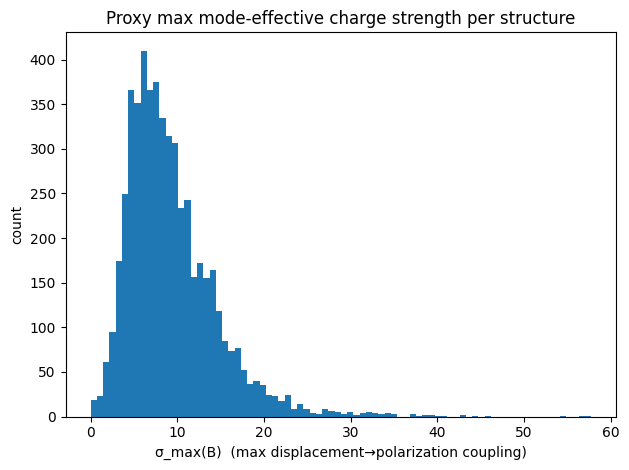

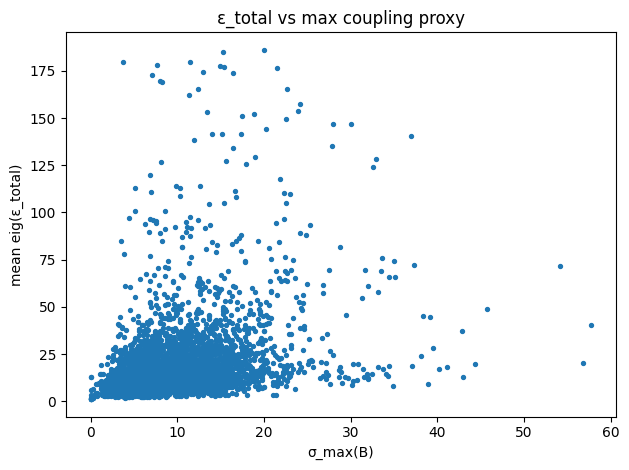

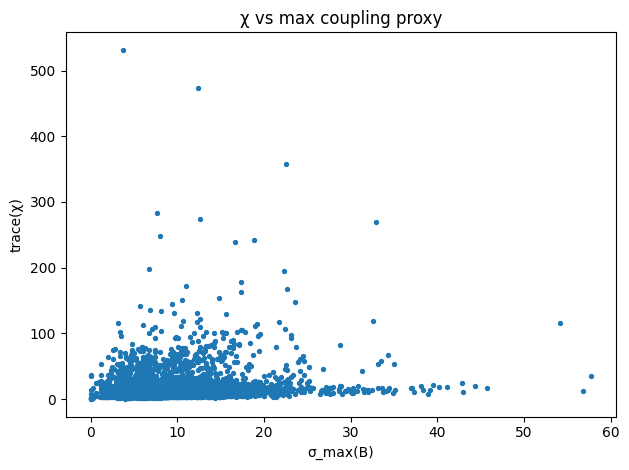

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def zstar_operator_norm(bec):
    """
    bec: (N,3,3) array for one structure
    returns sigma_max of B where B is (3, 3N) stacked Z* blocks
    """
    if bec is None:
        return np.nan
    Z = np.array(bec, dtype=float)
    if Z.ndim != 3 or Z.shape[1:] != (3,3):
        return np.nan
    N = Z.shape[0]
    B = np.zeros((3, 3*N), dtype=float)
    for k in range(N):
        B[:, 3*k:3*k+3] = Z[k]
    # largest singular value
    s = np.linalg.svd(B, compute_uv=False)
    return float(s[0]) if len(s) else np.nan

dfa["Zeff_sigma_max"] = dfa["bec"].apply(zstar_operator_norm)

# Plot distribution
plt.figure()
x = pd.to_numeric(dfa["Zeff_sigma_max"], errors="coerce").dropna().values
plt.hist(x, bins=80)
plt.xlabel("σ_max(B)  (max displacement→polarization coupling)")
plt.ylabel("count")
plt.title("Proxy max mode-effective charge strength per structure")
plt.tight_layout()
plt.show()

# Correlate with dielectric / chi
def scatter(x, y, xlabel, ylabel, title, s=8):
    xx = pd.to_numeric(x, errors="coerce")
    yy = pd.to_numeric(y, errors="coerce")
    m = (~xx.isna()) & (~yy.isna())
    plt.figure()
    plt.scatter(xx[m], yy[m], s=s)
    plt.xlabel(xlabel); plt.ylabel(ylabel); plt.title(title)
    plt.tight_layout(); plt.show()

scatter(dfa["Zeff_sigma_max"], dfa["eps_total_scalar"], "σ_max(B)", "mean eig(ε_total)", "ε_total vs max coupling proxy")
scatter(dfa["Zeff_sigma_max"], dfa["chi_trace"], "σ_max(B)", "trace(χ)", "χ vs max coupling proxy")

## Save summary tables
Writes CSVs with per-structure numeric summaries for later inspection.


In [20]:
from pathlib import Path

out_dir = Path("analysis_outputs")
out_dir.mkdir(exist_ok=True)

summary_cols = [
    "material_id","dielectric_task_id","n","volume","REF_energy","energy_per_atom",
    "max_force","stress_mag_gpa","eps_total_scalar","eps_eig_min","eps_eig_max","bec_asr_norm","chi_trace"
]
dfa[summary_cols].to_csv(out_dir / f"summary_{ANALYZE}.csv", index=False)

pd.DataFrame(elem_counts.most_common(), columns=["element","atom_count"]).to_csv(out_dir / f"element_atom_counts_{ANALYZE}.csv", index=False)
pd.DataFrame(struct_elem_counts.most_common(), columns=["element","structure_count"]).to_csv(out_dir / f"element_structure_counts_{ANALYZE}.csv", index=False)

print("Wrote:", out_dir)


Wrote: analysis_outputs


# Element-level diagnostics for filtering failures

This section analyzes **which elements are over-represented** in structures that fail your filters, to help identify where the dataset quality issues come from.

It assumes you already built:
- `df` = raw parsed dataframe (one row per structure)
- `df_f` = filtered dataframe (after applying your mask)

If your notebook uses different variable names, adjust the first cell accordingly.


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# --- choose the raw and kept dataframes ---
RAW = df.copy()
KEPT = df_f.copy()

if "filter_source_index" in KEPT.columns and KEPT["filter_source_index"].notna().any():
    kept_ids = set(pd.to_numeric(KEPT["filter_source_index"], errors="coerce").dropna().astype(int))
    RAW["kept"] = RAW["i"].astype(int).isin(kept_ids)
elif "i" in RAW.columns and "i" in KEPT.columns and len(RAW) == len(KEPT):
    kept_ids = set(KEPT["i"].astype(int).values)
    RAW["kept"] = RAW["i"].astype(int).isin(kept_ids)
else:
    if "material_id" in RAW.columns and "material_id" in KEPT.columns:
        kept_mids = set(KEPT["material_id"].astype(str).values)
        RAW["kept"] = RAW["material_id"].astype(str).isin(kept_mids)
    else:
        RAW["kept"] = False

print("raw:", len(RAW), "kept:", int(RAW["kept"].sum()), "dropped:", int((~RAW["kept"]).sum()))


raw: 7332 kept: 5281 dropped: 2051


## Reconstruct per-filter failure flags

We rebuild the same kinds of flags used in filtering. If your thresholds differ, set them here to match the filtering cell above.

In [22]:
def symmetrize(eps):
    e = np.array(eps, dtype=float).reshape(3,3)
    return 0.5*(e + e.T)

def eps_min_eig(eps):
    if eps is None:
        return np.nan
    try:
        w = np.linalg.eigvalsh(symmetrize(eps))
        return float(np.min(w))
    except Exception:
        return np.nan

def eps_mean_eig(eps):
    if eps is None:
        return np.nan
    try:
        w = np.linalg.eigvalsh(symmetrize(eps))
        return float(np.mean(w))
    except Exception:
        return np.nan

def max_force_from_forces(at):
    f = at.arrays.get("REF_forces", None)
    if f is None:
        return np.nan
    try:
        f = np.array(f, dtype=float)
        return float(np.max(np.linalg.norm(f, axis=1)))
    except Exception:
        return np.nan

def stress_mag_from_info(at):
    s = at.info.get("REF_stress", None)
    if s is None:
        return np.nan
    try:
        s = np.array(s, dtype=float).reshape(-1)
        return float(np.max(np.abs(s)))
    except Exception:
        return np.nan

def bec_asr_norm(bec):
    if bec is None:
        return np.nan
    try:
        S = np.sum(np.array(bec, dtype=float), axis=0)
        return float(np.linalg.norm(S))
    except Exception:
        return np.nan

# Ensure derived columns exist
if "max_force" not in RAW.columns:
    RAW["max_force"] = RAW["atoms"].apply(max_force_from_forces)

if "stress_mag_ev_a3" not in RAW.columns:
    RAW["stress_mag_ev_a3"] = RAW["atoms"].apply(stress_mag_from_info)

if "bec_asr_norm" not in RAW.columns:
    RAW["bec_asr_norm"] = RAW["bec"].apply(bec_asr_norm)

if "eps_min_eig" not in RAW.columns:
    RAW["eps_min_eig"] = RAW["eps_total"].apply(eps_min_eig)

if "eps_total_scalar" not in RAW.columns:
    RAW["eps_total_scalar"] = RAW["eps_total"].apply(eps_mean_eig)

for c in ["max_force","stress_mag_ev_a3","bec_asr_norm","eps_min_eig","eps_total_scalar"]:
    RAW[c] = pd.to_numeric(RAW[c], errors="coerce")

# --- thresholds: set these to match your filtering ---
MAX_FORCE_EV_PER_A = 0.05
MAX_ASR_NORM = 0.3
MIN_EPS_EIG = 0.8
MAX_EPS_SCALAR = 200.0

GPA_PER_EV_A3 = 160.21766208
MAX_STRESS_GPA = 5.0
MAX_STRESS_EV_A3 = MAX_STRESS_GPA / GPA_PER_EV_A3

# --- failure flags ---
RAW["fail_missing_bec"] = RAW["bec"].isna()
RAW["fail_missing_eps"] = RAW["eps_total"].isna()
RAW["fail_missing_pol"] = RAW["REF_polarizability"].isna() if "REF_polarizability" in RAW.columns else False

RAW["fail_eps_min_eig"] = RAW["eps_min_eig"].notna() & (RAW["eps_min_eig"] < MIN_EPS_EIG)
RAW["fail_eps_scalar"] = (RAW["eps_total_scalar"].notna() & ((RAW["eps_total_scalar"] <= 0) | (RAW["eps_total_scalar"] > MAX_EPS_SCALAR)))

RAW["fail_max_force"] = RAW["max_force"].notna() & (RAW["max_force"] > MAX_FORCE_EV_PER_A)
RAW["fail_asr"] = RAW["bec_asr_norm"].notna() & (RAW["bec_asr_norm"] > MAX_ASR_NORM)
RAW["fail_stress"] = RAW["stress_mag_ev_a3"].notna() & (RAW["stress_mag_ev_a3"] > MAX_STRESS_EV_A3)

fail_cols = [c for c in RAW.columns if c.startswith("fail_")]
RAW["n_fail"] = RAW[fail_cols].sum(axis=1)

RAW[fail_cols + ["n_fail","kept"]].mean().sort_values(ascending=False)


kept                0.720267
n_fail              0.296781
fail_max_force      0.242089
fail_asr            0.041871
fail_eps_scalar     0.009138
fail_stress         0.003682
fail_missing_eps    0.000000
fail_missing_bec    0.000000
fail_missing_pol    0.000000
fail_eps_min_eig    0.000000
dtype: float64

## Element enrichment: which elements appear more in dropped vs kept structures?

In [23]:
def count_elements(rows):
    atom_counts = Counter()
    struct_counts = Counter()
    for at in rows:
        syms = at.get_chemical_symbols()
        atom_counts.update(syms)
        struct_counts.update(set(syms))
    return atom_counts, struct_counts

kept_atoms = RAW.loc[RAW["kept"], "atoms"].values
drop_atoms = RAW.loc[~RAW["kept"], "atoms"].values

atom_kept, struct_kept = count_elements(kept_atoms)
atom_drop, struct_drop = count_elements(drop_atoms)

elems = sorted(set(atom_kept.keys()) | set(atom_drop.keys()))

def enrich(a_drop, a_kept, eps=1.0):
    return (a_drop + eps) / (a_kept + eps)

rows = []
for e in elems:
    rows.append({
        "element": e,
        "atom_kept": atom_kept.get(e, 0),
        "atom_drop": atom_drop.get(e, 0),
        "atom_enrich_drop_over_kept": enrich(atom_drop.get(e,0), atom_kept.get(e,0), eps=1.0),
        "struct_kept": struct_kept.get(e, 0),
        "struct_drop": struct_drop.get(e, 0),
        "struct_enrich_drop_over_kept": enrich(struct_drop.get(e,0), struct_kept.get(e,0), eps=1.0),
    })

enrich_df = pd.DataFrame(rows).sort_values("struct_enrich_drop_over_kept", ascending=False)
enrich_df.head(25)


,element,atom_kept,atom_drop,atom_enrich_drop_over_kept,struct_kept,struct_drop,struct_enrich_drop_over_kept
37,Lu,50,37,0.745098,7,8,1.125000
23,Fe,352,631,1.790368,137,145,1.057971
27,H,2843,3714,1.306259,327,344,1.051829
10,C,585,614,1.049488,132,137,1.037594
0,Ac,4,2,0.600000,1,1,1.000000
73,U,7,4,0.625000,2,2,1.000000
39,Mn,465,704,1.512876,179,176,0.983333
36,Li,2943,2863,0.972826,565,539,0.954064
15,Co,208,210,1.009569,79,75,0.950000
72,Tm,76,71,0.935065,15,13,0.875000


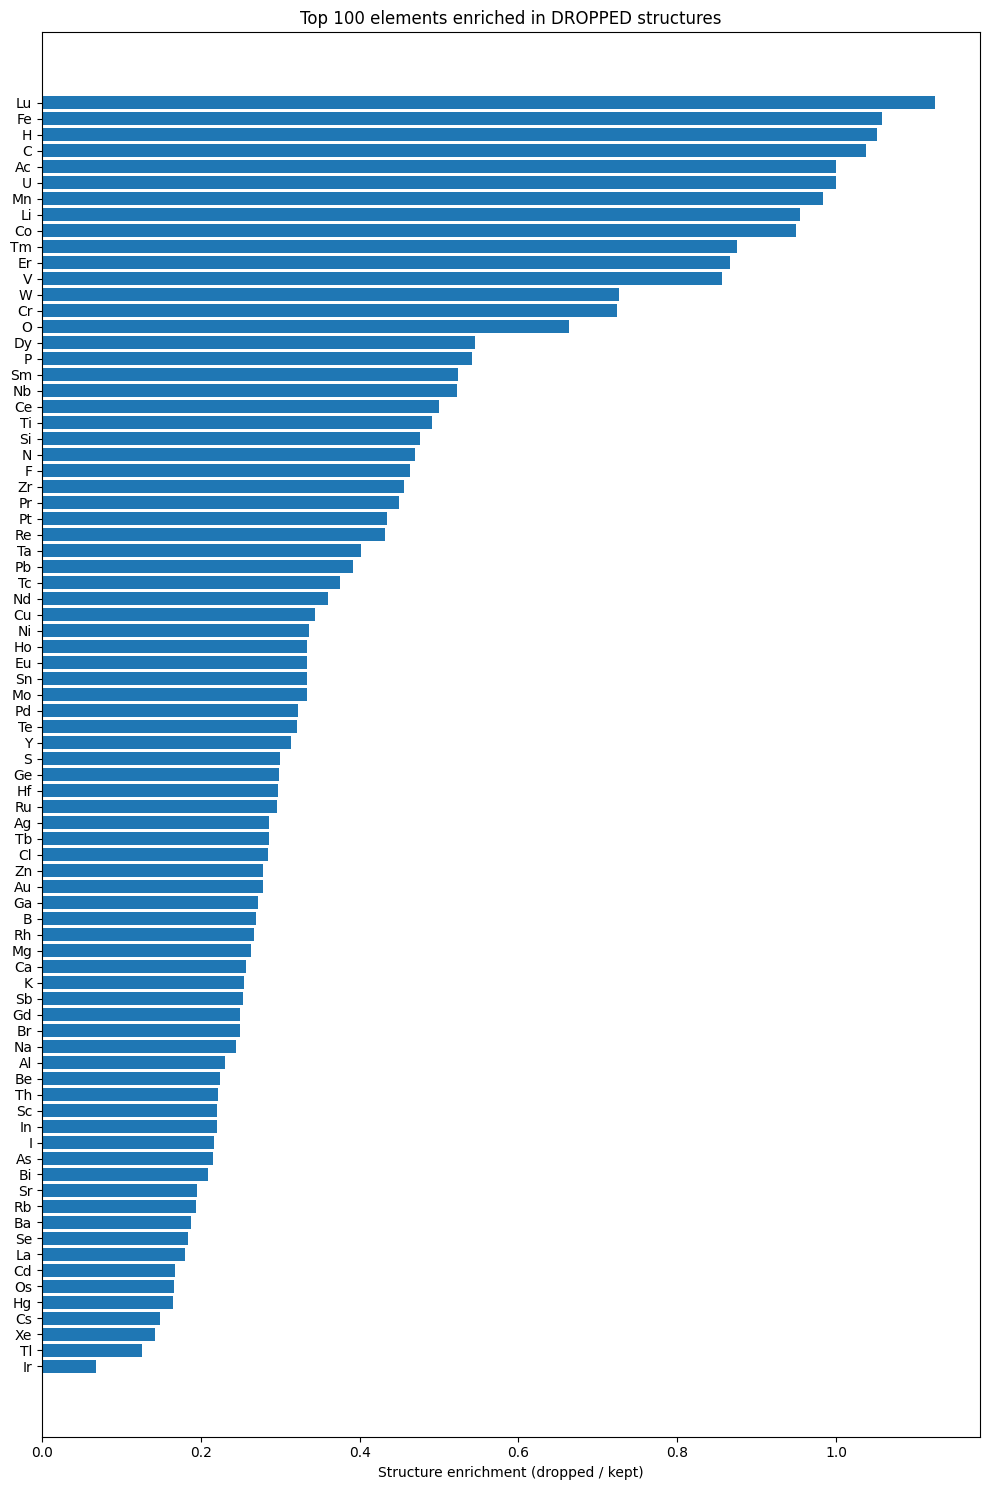

In [24]:
TOPK = 100
top = enrich_df.head(TOPK).iloc[::-1]

plt.figure(figsize=(10,15))
plt.barh(top["element"], top["struct_enrich_drop_over_kept"])
plt.xlabel("Structure enrichment (dropped / kept)")
plt.title(f"Top {TOPK} elements enriched in DROPPED structures")
plt.tight_layout()
plt.show()


## Which filter is each element failing?


In [25]:
from collections import defaultdict

elem_struct_total = Counter()
elem_fail_counts = {fc: Counter() for fc in fail_cols}

for _, row in RAW.iterrows():
    at = row["atoms"]
    syms = set(at.get_chemical_symbols())
    for e in syms:
        elem_struct_total[e] += 1
        for fc in fail_cols:
            if bool(row[fc]):
                elem_fail_counts[fc][e] += 1

fail_rate_rows = []
for e, total in elem_struct_total.items():
    r = {"element": e, "n_structs": total}
    for fc in fail_cols:
        r[fc.replace("fail_", "rate_")] = elem_fail_counts[fc][e] / total
    fail_rate_rows.append(r)

fail_rate_df = pd.DataFrame(fail_rate_rows).sort_values("n_structs", ascending=False)
fail_rate_df.head()


,element,n_structs,rate_missing_bec,rate_missing_eps,rate_missing_pol,rate_eps_min_eig,rate_eps_scalar,rate_max_force,rate_asr,rate_stress
20,O,3423,0.0,0.0,0.0,0.0,0.006427,0.372480,0.035641,0.005551
23,Li,1104,0.0,0.0,0.0,0.0,0.007246,0.467391,0.028080,0.005435
15,F,1017,0.0,0.0,0.0,0.0,0.001967,0.281219,0.054081,0.011799
2,S,860,0.0,0.0,0.0,0.0,0.010465,0.187209,0.044186,0.000000
11,P,735,0.0,0.0,0.0,0.0,0.002721,0.314286,0.042177,0.000000


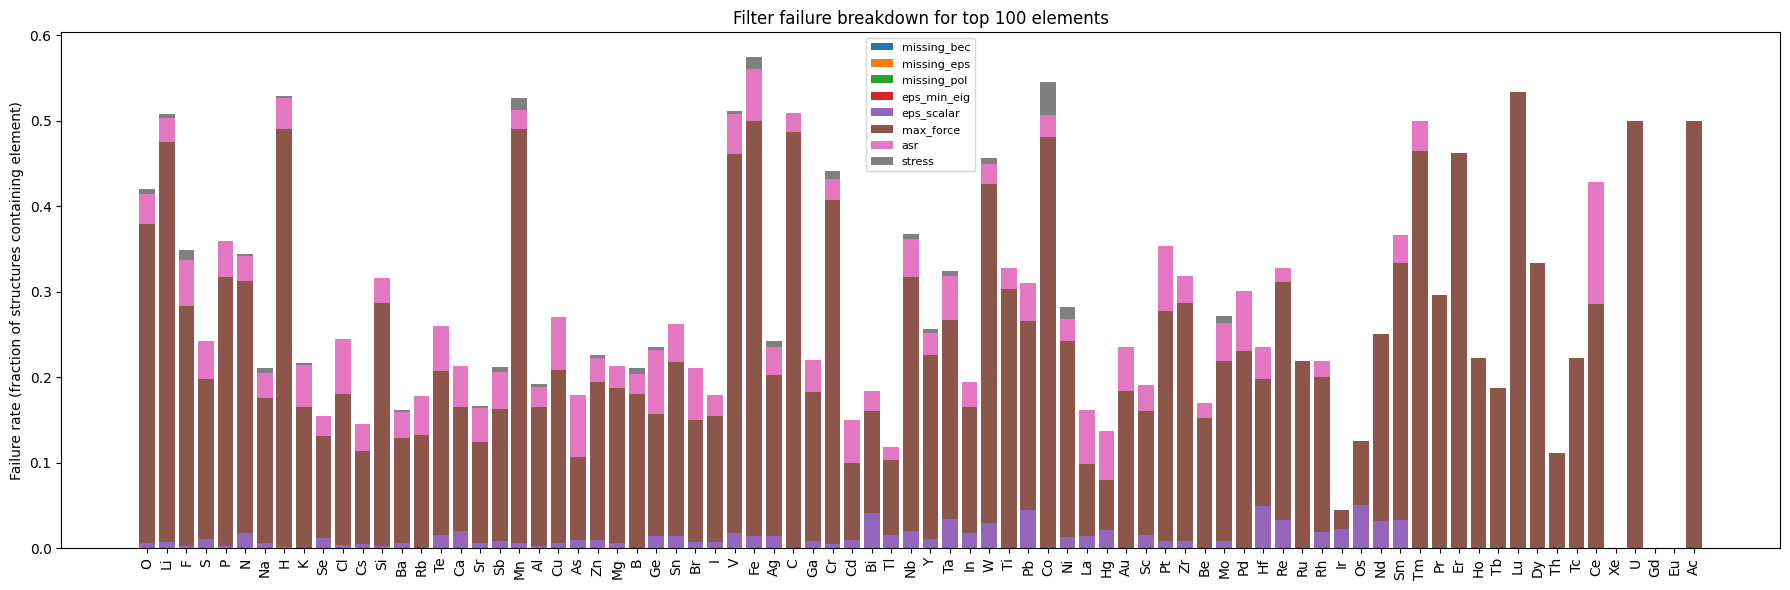

In [26]:
TOP_ELEMS = 100
top_elems = fail_rate_df.head(TOP_ELEMS)
rate_cols = [c for c in fail_rate_df.columns if c.startswith("rate_")]

plt.figure(figsize=(18,6))
x = np.arange(len(top_elems))
bottom = np.zeros(len(top_elems))

for rc in rate_cols:
    vals = top_elems[rc].values
    plt.bar(x, vals, bottom=bottom, label=rc.replace("rate_", ""))
    bottom += vals

plt.xticks(x, top_elems["element"].values, rotation=90)
plt.ylabel("Failure rate (fraction of structures containing element)")
plt.title(f"Filter failure breakdown for top {TOP_ELEMS} elements")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [27]:
ELEMENT = "O"          # change
FAIL_COL = None        # e.g. "fail_asr" or "fail_max_force" or None for any-drop

sub = RAW.copy()
sub["has_element"] = sub["atoms"].apply(lambda at: ELEMENT in set(at.get_chemical_symbols()))

if FAIL_COL is not None:
    sub = sub[sub["has_element"] & sub[FAIL_COL] & (~sub["kept"])]
else:
    sub = sub[sub["has_element"] & (~sub["kept"])]

cols_show = ["material_id","dielectric_task_id","n","max_force","stress_mag_ev_a3","eps_min_eig","eps_total_scalar","bec_asr_norm"] + fail_cols
sub[cols_show].head(30)


,material_id,dielectric_task_id,n,max_force,stress_mag_ev_a3,eps_min_eig,eps_total_scalar,bec_asr_norm,fail_missing_bec,fail_missing_eps,fail_missing_pol,fail_eps_min_eig,fail_eps_scalar,fail_max_force,fail_asr,fail_stress
38,mp-32854,mp-1116273,19,0.131449,0.003519,2.754288,5.661699,0.000041,False,False,False,False,False,True,False,False
42,mp-556588,mp-1118239,12,0.075745,0.000834,5.574145,6.321018,0.000020,False,False,False,False,False,True,False,False
44,mp-556880,mp-1117844,12,0.065279,0.000221,3.721669,4.247948,0.000028,False,False,False,False,False,True,False,False
45,mp-556985,mp-1114911,12,0.073845,0.000919,3.108684,3.467681,0.001023,False,False,False,False,False,True,False,False
46,mp-556994,mp-1114903,12,0.059145,0.000814,3.486701,3.944354,0.000967,False,False,False,False,False,True,False,False
49,mp-752826,mp-1117949,25,0.104200,0.001094,7.984336,8.806849,0.000048,False,False,False,False,False,True,False,False
50,mp-974002,mp-1140690,8,0.364684,0.042393,3.231165,6.299658,0.007925,False,False,False,False,False,True,False,True
55,mp-32959,mp-1114916,6,0.053213,0.003515,2.606784,3.874392,0.000273,False,False,False,False,False,True,False,False
70,mp-559122,mp-1142018,16,0.065071,0.000265,31.271025,101.259681,0.091210,False,False,False,False,False,True,False,False
75,mp-600001,mp-1141046,15,0.093313,0.002486,2.915023,3.004850,0.052039,False,False,False,False,False,True,False,False


In [28]:
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def element_failure_enrichment(df, fail_col):
    elem_total = Counter()
    elem_fail = Counter()

    for _, row in df.iterrows():
        syms = set(row["atoms"].get_chemical_symbols())
        for e in syms:
            elem_total[e] += 1
            if row[fail_col]:
                elem_fail[e] += 1

    rows = []
    for e in elem_total:
        total = elem_total[e]
        fail = elem_fail[e]
        rows.append({
            "element": e,
            "n_structures": total,
            "n_fail": fail,
            "fail_rate": fail / total
        })

    out = pd.DataFrame(rows)
    return out.sort_values("fail_rate", ascending=False)

max_force_elem = element_failure_enrichment(RAW, "fail_max_force")
max_force_elem.head(25)

,element,n_structures,n_fail,fail_rate
78,Lu,15,8,0.533333
79,U,4,2,0.500000
65,Ac,2,1,0.500000
1,H,671,328,0.488823
7,C,269,131,0.486989
44,Fe,282,137,0.485816
30,Mn,355,172,0.484507
56,Co,154,74,0.480519
23,Li,1104,516,0.467391
75,Tm,28,13,0.464286


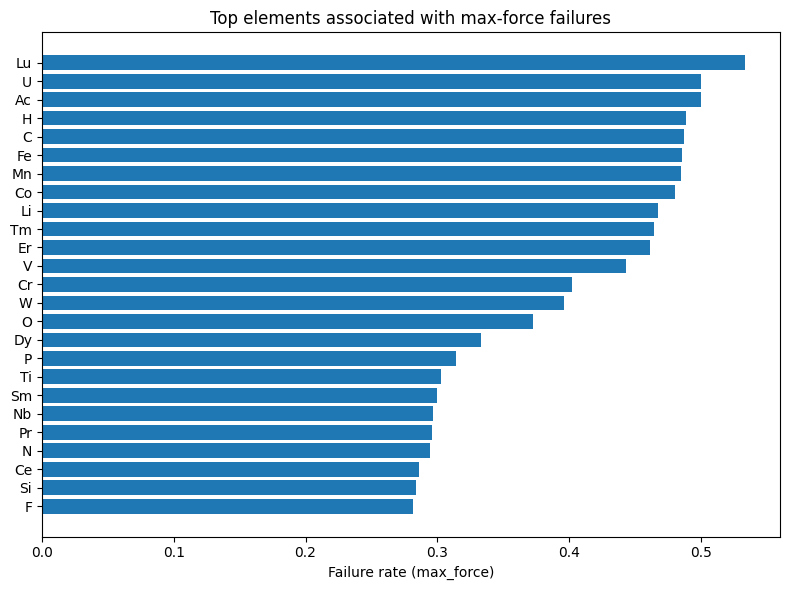

In [29]:
TOPK = 25
top = max_force_elem.head(TOPK).iloc[::-1]

plt.figure(figsize=(8,6))
plt.barh(top["element"], top["fail_rate"])
plt.xlabel("Failure rate (max_force)")
plt.title("Top elements associated with max-force failures")
plt.tight_layout()
plt.show()

In [30]:
bec_asr_elem = element_failure_enrichment(RAW, "fail_asr")
bec_asr_elem.head(25)

,element,n_structures,n_fail,fail_rate
66,Ce,7,1,0.142857
53,Pt,130,10,0.076923
10,Ge,294,22,0.074830
28,As,319,23,0.072100
60,Pd,113,8,0.070796
0,Cl,499,32,0.064128
59,La,142,9,0.063380
40,Cu,322,20,0.062112
13,Br,294,18,0.061224
44,Fe,282,17,0.060284


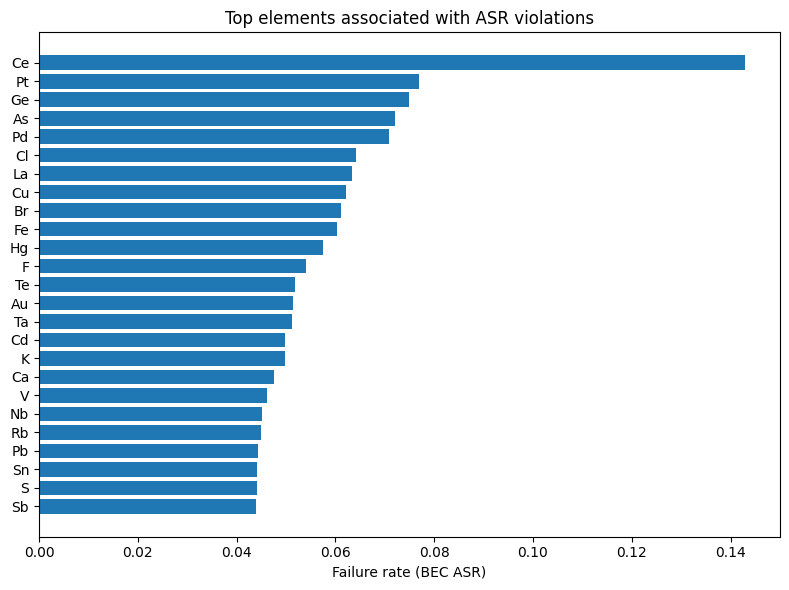

In [31]:
TOPK = 25
top = bec_asr_elem.head(TOPK).iloc[::-1]

plt.figure(figsize=(8,6))
plt.barh(top["element"], top["fail_rate"])
plt.xlabel("Failure rate (BEC ASR)")
plt.title("Top elements associated with ASR violations")
plt.tight_layout()
plt.show()

In [32]:
compare = max_force_elem.set_index("element")[["fail_rate"]].rename(columns={"fail_rate":"max_force_rate"})
compare = compare.join(
    bec_asr_elem.set_index("element")[["fail_rate"]].rename(columns={"fail_rate":"asr_rate"}),
    how="outer"
).fillna(0)

compare = compare.sort_values("max_force_rate", ascending=False)
compare.head(25)

,max_force_rate,asr_rate
element,,
Lu,0.533333,0.000000
U,0.500000,0.000000
Ac,0.500000,0.000000
H,0.488823,0.035768
C,0.486989,0.022305
Fe,0.485816,0.060284
Mn,0.484507,0.022535
Co,0.480519,0.025974
Li,0.467391,0.028080


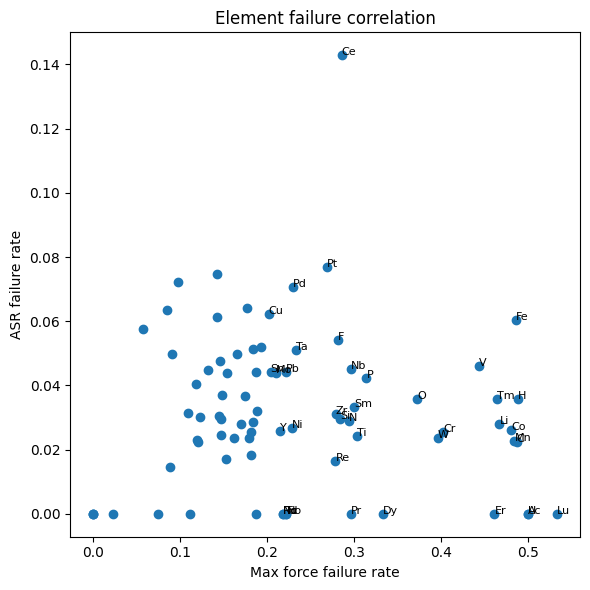

In [33]:
plt.figure(figsize=(6,6))
plt.scatter(compare["max_force_rate"], compare["asr_rate"])

for e, row in compare.iterrows():
    if row["max_force_rate"] > 0.2 or row["asr_rate"] > 0.2:
        plt.text(row["max_force_rate"], row["asr_rate"], e, fontsize=8)

plt.xlabel("Max force failure rate")
plt.ylabel("ASR failure rate")
plt.title("Element failure correlation")
plt.tight_layout()
plt.show()

In [34]:
ELEMENT = "O"

sub = RAW[
    (RAW["fail_max_force"]) &
    (RAW["atoms"].apply(lambda at: ELEMENT in set(at.get_chemical_symbols())))
]

sub[["material_id","max_force","n","eps_total_scalar","bec_asr_norm"]].head(20)

,material_id,max_force,n,eps_total_scalar,bec_asr_norm
38,mp-32854,0.131449,19,5.661699,0.000041
42,mp-556588,0.075745,12,6.321018,0.000020
44,mp-556880,0.065279,12,4.247948,0.000028
45,mp-556985,0.073845,12,3.467681,0.001023
46,mp-556994,0.059145,12,3.944354,0.000967
49,mp-752826,0.104200,25,8.806849,0.000048
50,mp-974002,0.364684,8,6.299658,0.007925
55,mp-32959,0.053213,6,3.874392,0.000273
70,mp-559122,0.065071,16,101.259681,0.091210
75,mp-600001,0.093313,15,3.004850,0.052039


In [35]:
ELEMENT = "O"

sub = RAW[
    (RAW["fail_asr"]) &
    (RAW["atoms"].apply(lambda at: ELEMENT in set(at.get_chemical_symbols())))
]

sub[["material_id","bec_asr_norm","n","max_force","eps_total_scalar"]].head(20)

,material_id,bec_asr_norm,n,max_force,eps_total_scalar
231,mp-28933,1.267732,40,0.024329,7.154830
430,mp-31050,0.396642,18,0.013809,3.136874
503,mp-510421,126.667178,16,0.021305,7.031181
521,mp-760432,3.166553,40,0.301993,24.486508
581,mp-23207,0.338774,24,0.030985,3.949757
751,mp-634812,82.665911,24,0.220938,22.832216
752,mp-7648,167.527782,24,0.011556,12.744677
983,mp-717,124.266815,20,0.013454,7.035235
987,mp-754401,124.685342,20,0.090279,7.760309
990,mp-753740,63.340581,8,0.059573,24.853994


In [36]:
import pandas as pd
import numpy as np

def chemical_formula(at):
    try:
        return at.get_chemical_formula(mode="hill")
    except Exception:
        return None

N = 50  # <-- set this

RAW["formula"] = RAW["atoms"].apply(chemical_formula)

top_force = (
    RAW.assign(max_force_num=pd.to_numeric(RAW["max_force"], errors="coerce"))
       .dropna(subset=["max_force_num"])
       .sort_values("max_force_num", ascending=False)
       .head(N)[["material_id", "formula", "max_force_num", "n"]]
       .rename(columns={"max_force_num": "max_force_eV_per_A"})
)

top_force

,material_id,formula,max_force_eV_per_A,n
5441,mp-1399089,MoO6WZn2,98.693304,10
5438,mp-1383360,F5Li2OV2,64.494212,10
5436,mp-1344419,B4Li3Mn4O12,21.123645,23
3170,mp-1398557,Ag2F6Li2,13.018826,10
1354,mp-1390750,Cr4F11O,6.823338,16
5435,mp-1344128,F11Li6Mn2O,4.605050,20
5063,mp-850713,C4Bi8O20,2.624602,32
5427,mp-1047724,AlCoO8W2,2.136601,12
3110,mp-19178,Ag2Co2O4,1.912308,8
2858,mp-18921,CoNaO2,1.598101,4


In [37]:
N = 95

top_asr = (
    RAW.assign(bec_asr_num=pd.to_numeric(RAW["bec_asr_norm"], errors="coerce"))
       .dropna(subset=["bec_asr_num"])
       .sort_values("bec_asr_num", ascending=False)
       .head(N)[["material_id", "formula", "bec_asr_num", "n"]]
       .rename(columns={"bec_asr_num": "bec_asr_norm"})
)

top_asr

,material_id,formula,bec_asr_norm,n
4224,mp-768223,Ce4Cs8O12,290.451854,24
4164,mp-21521,Cs8O12Pb4,262.206582,24
4218,mp-756156,O12Rb8Zr4,249.467753,24
4163,mp-21489,O12Pb4Rb8,241.039583,24
4207,mp-753798,O12Rb8Sn4,231.328142,24
...,...,...,...,...
990,mp-753740,Cr2O6,63.340581,8
4654,mp-4009,Ba2Pd2S4,62.236415,8
3573,mp-753571,F6LiV,60.654120,8
4728,mp-8212,CdO6Pt3,59.316273,10


In [38]:
N = 50  # <-- set this

tmp = RAW.copy()
tmp["formula"] = tmp["atoms"].apply(chemical_formula)
tmp["max_force_num"] = pd.to_numeric(tmp.get("max_force"), errors="coerce")
tmp["bec_asr_num"] = pd.to_numeric(tmp.get("bec_asr_norm"), errors="coerce")

top_force_ids = set(tmp.dropna(subset=["max_force_num"]).nlargest(N, "max_force_num")["material_id"].astype(str))
top_asr_ids   = set(tmp.dropna(subset=["bec_asr_num"]).nlargest(N, "bec_asr_num")["material_id"].astype(str))

union = tmp[tmp["material_id"].astype(str).isin(top_force_ids | top_asr_ids)].copy()

union = union.sort_values(
    ["bec_asr_num", "max_force_num"],
    ascending=[False, False]
)[["material_id","formula","max_force_num","bec_asr_num","n"]].rename(columns={
    "max_force_num": "max_force_eV_per_A",
    "bec_asr_num": "bec_asr_norm"
})

union

,material_id,formula,max_force_eV_per_A,bec_asr_norm,n
4224,mp-768223,Ce4Cs8O12,0.067195,290.451854,24
4164,mp-21521,Cs8O12Pb4,0.126912,262.206582,24
4218,mp-756156,O12Rb8Zr4,0.037780,249.467753,24
4163,mp-21489,O12Pb4Rb8,0.118630,241.039583,24
4207,mp-753798,O12Rb8Sn4,0.073929,231.328142,24
...,...,...,...,...,...
1353,mp-1295909,Mn2O7V2,0.639496,0.000020,11
36,mp-1402840,F8W2,0.757930,0.000020,10
1657,mp-763481,Co2Nb4O12,0.845597,0.000020,18
5001,mp-34501,Co4Fe8O16,1.252154,0.000020,28


In [39]:
np.asarray(tmp["atoms"][4224].arrays['REF_becs']).reshape(-1,3,3)

array([[[ 1.101596e+01, -1.600000e-04,  4.957000e-02],
        [-3.000000e-05,  1.101282e+01, -3.290000e-03],
        [ 1.398000e-02,  2.733000e-02,  1.185750e+00]],

       [[ 1.101057e+01, -1.600000e-04,  4.957000e-02],
        [ 3.000000e-05,  1.101282e+01, -3.290000e-03],
        [-1.398000e-02,  2.733000e-02,  1.185750e+00]],

       [[ 1.101057e+01,  1.600000e-04,  4.957000e-02],
        [ 3.000000e-05,  1.101371e+01, -3.290000e-03],
        [-1.398000e-02, -2.733000e-02,  1.185760e+00]],

       [[ 1.101596e+01,  1.600000e-04,  4.957000e-02],
        [-3.000000e-05,  1.101371e+01, -3.290000e-03],
        [ 1.398000e-02, -2.733000e-02,  1.185760e+00]],

       [[ 1.101596e+01, -1.600000e-04,  4.957000e-02],
        [-3.000000e-05,  1.101282e+01, -3.290000e-03],
        [ 1.398000e-02,  2.733000e-02,  1.185750e+00]],

       [[ 1.101057e+01, -1.600000e-04,  4.957000e-02],
        [ 3.000000e-05,  1.101282e+01, -3.290000e-03],
        [-1.398000e-02,  2.733000e-02,  1.185750e+00]],